In [29]:
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller

In [2]:
def prep_price_matrix(df_list):
    """
    Extracts the mid_price from the list of DataFrames and aligns them by timestamp.
    Returns a single DataFrame where each column is a product.
    """
    prices = {}
    for df in df_list:
        product_name = df['product'].iloc[0]
        # Set timestamp as index and extract mid_price
        prices[product_name] = df['mid_price']
    
    # Concat along columns and drop any rows with missing data
    price_matrix = pd.concat(prices, axis=1).dropna()
    return price_matrix

In [3]:
def calculate_half_life(spread_series):
    """Calculates the Ornstein-Uhlenbeck mean-reversion half-life."""
    spread_lag = spread_series.shift(1).dropna()
    spread_diff = spread_series.diff().dropna()
    
    # Regress delta_S against S_lag
    coef = np.polyfit(spread_lag, spread_diff, 1)
    lam = coef[0]
    
    # If lambda is >= 0, it is not mean-reverting
    if lam >= 0:
        return np.inf
    
    return -np.log(2) / lam

In [4]:
def find_smallest_optimal_baskets(df_list):
    """
    Uses Johansen cointegration to anchor an integer search space,
    prioritizing the smallest possible integer weights.
    """
    price_df = prep_price_matrix(df_list)
    product_names = price_df.columns.tolist()
    
    # 1. Run Johansen Cointegration Test to get continuous weights
    # print(f"Running Johansen Test for: {product_names}...")
    johansen_res = coint_johansen(price_df, det_order=0, k_ar_diff=1)
    
    # The first eigenvector corresponds to the strongest cointegrating relationship
    raw_weights = johansen_res.evec[:, 0]
    
    # Normalize so the largest absolute weight is exactly 1.0
    norm_weights = raw_weights / np.max(np.abs(raw_weights))
    
    results = []
    tested_combinations = set()
    prices_array = price_df.values
    
    # 2. Integer Grid Search (Iterating from smallest scale to largest)
    # print("Searching integer space...")
    for scale in range(1, 11):
        # Scale the normalized weights to integer anchors
        base_integers = np.round(norm_weights * scale)
        
        # Create a local grid (+/- 1) around the base integers
        grid_ranges = [range(int(w) - 1, int(w) + 2) for w in base_integers]
        
        for int_w in itertools.product(*grid_ranges):
            # Normalize sign to avoid testing inverse duplicates (e.g. [1, -1] and [-1, 1])
            first_nonzero = next((w for w in int_w if w != 0), 0)
            if first_nonzero < 0:
                int_w = tuple(-w for w in int_w)
                
            if int_w in tested_combinations:
                continue
            tested_combinations.add(int_w)
            
            # Strict Constraints
            if all(w == 0 for w in int_w): 
                continue
            
            max_abs_weight = max(abs(w) for w in int_w)
            # Skip if any weight exceeds the absolute position limit of 10
            if max_abs_weight > 10: 
                continue
                
            # 3. Calculate Spread and evaluate
            spread = pd.Series(np.dot(prices_array, int_w))
            
            try:
                # Fast ADF test (maxlag=1 for speed on high frequency data)
                adf_stat, p_val, _, _, _, _ = adfuller(spread, maxlag=1)
                
                # If highly stationary, compute half life
                if p_val < 0.05:
                    hl = calculate_half_life(spread)
                    if hl < np.inf:
                        results.append({
                            'Weights': int_w,
                            'Max_Weight': max_abs_weight,
                            'Sum_Abs_Weights': sum(abs(w) for w in int_w),
                            'ADF_PValue': p_val,
                            'Half_Life': hl
                        })
            except:
                continue

    # 4. Format and Sort Results
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        # Sort explicitly to find the SMALLEST max_weight first, 
        # followed by the best P-Value and fastest Half-Life
        results_df = results_df.sort_values(['Max_Weight', 'ADF_PValue', 'Half_Life']).reset_index(drop=True)
        
        print("\n--- Top 10 Smallest Tradeable Baskets ---")
        print(f"Asset Order: {product_names}")
        print(results_df.head(10).to_string())
        return results_df, product_names
    else:
        print("No stationary integer combinations found.")
        return None, product_names

In [32]:
def get_ema_thrs(price_arr, window_size, init_mean, init_std):
    ema_mean = init_mean
    ema_var = init_std ** 2

    alpha = 2 / (window_size + 1)
    
    estimated_means = []
    estimated_stds = []
    
    # 3. EMA Updating Loop
    for price in price_arr:
        diff = price - ema_mean
        ema_var = (1 - alpha) * ema_var + alpha * (diff ** 2)
        ema_mean = ema_mean + (alpha * diff)
        current_std = math.sqrt(ema_var)
        
        estimated_means.append(ema_mean)
        estimated_stds.append(current_std)

    return np.array(estimated_means), np.array(estimated_stds)

In [5]:
groups_str = \
"""- **Galaxy Sounds Recorders**: `GALAXY_SOUNDS_DARK_MATTER`, `GALAXY_SOUNDS_BLACK_HOLES`, `GALAXY_SOUNDS_PLANETARY_RINGS`, `GALAXY_SOUNDS_SOLAR_WINDS`, `GALAXY_SOUNDS_SOLAR_FLAMES`
- **Vertical Sleeping Pods**: `SLEEP_POD_SUEDE`, `SLEEP_POD_LAMB_WOOL`, `SLEEP_POD_POLYESTER`, `SLEEP_POD_NYLON`, `SLEEP_POD_COTTON`
- **Organic Microchips**: `MICROCHIP_CIRCLE`, `MICROCHIP_OVAL`, `MICROCHIP_SQUARE`, `MICROCHIP_RECTANGLE`, `MICROCHIP_TRIANGLE`
- **Purification Pebbles**: `PEBBLES_XS`, `PEBBLES_S`, `PEBBLES_M`, `PEBBLES_L`, `PEBBLES_XL`
- **Domestic Robots**: `ROBOT_VACUUMING`, `ROBOT_MOPPING`, `ROBOT_DISHES`, `ROBOT_LAUNDRY`, `ROBOT_IRONING`
- **UV-Visors**: `UV_VISOR_YELLOW`, `UV_VISOR_AMBER`, `UV_VISOR_ORANGE`, `UV_VISOR_RED`, `UV_VISOR_MAGENTA`
- **Instant Translators**: `TRANSLATOR_SPACE_GRAY`, `TRANSLATOR_ASTRO_BLACK`, `TRANSLATOR_ECLIPSE_CHARCOAL`, `TRANSLATOR_GRAPHITE_MIST`, `TRANSLATOR_VOID_BLUE`
- **Construction Panels**: `PANEL_1X2`, `PANEL_2X2`, `PANEL_1X4`, `PANEL_2X4`, `PANEL_4X4`
- **Liquid Breath Oxygen Shakes**: `OXYGEN_SHAKE_MORNING_BREATH`, `OXYGEN_SHAKE_EVENING_BREATH`, `OXYGEN_SHAKE_MINT`, `OXYGEN_SHAKE_CHOCOLATE`, `OXYGEN_SHAKE_GARLIC`
- **Protein Snack Packs**: `SNACKPACK_CHOCOLATE`, `SNACKPACK_VANILLA`, `SNACKPACK_PISTACHIO`, `SNACKPACK_STRAWBERRY`, `SNACKPACK_RASPBERRY`"""

In [6]:
price = pd.read_csv('../data/raw/round_5/prices_round_5_day_2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_1 = pd.read_csv('../data/raw/round_5/prices_round_5_day_3.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_2 = pd.read_csv('../data/raw/round_5/prices_round_5_day_4.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])

In [7]:
trans_table = str.maketrans('', '', " *-`'")
rows = groups_str.split('\n')
groups = [row.translate(trans_table).split(':')[1].split(',') for row in rows]

In [8]:
prices, prices_1, prices_2 = [], [], []
for gr in groups:
    prices.append([price[price['product'] == g].set_index("timestamp", drop=True) for g in gr])
    prices_1.append([price_1[price_1['product'] == g].set_index("timestamp", drop=True) for g in gr])
    prices_2.append([price_2[price_2['product'] == g].set_index("timestamp", drop=True) for g in gr])

In [9]:
prices_flat = []
for p in prices:
    prices_flat.extend(p)
prices_flat_1 = []
for p in prices_1:
    prices_flat_1.extend(p)
prices_flat_2 = []
for p in prices_2:
    prices_flat_2.extend(p)

In [10]:
np.unique([p.iloc[0]['mid_price'] for p in prices_flat])

array([10000.])

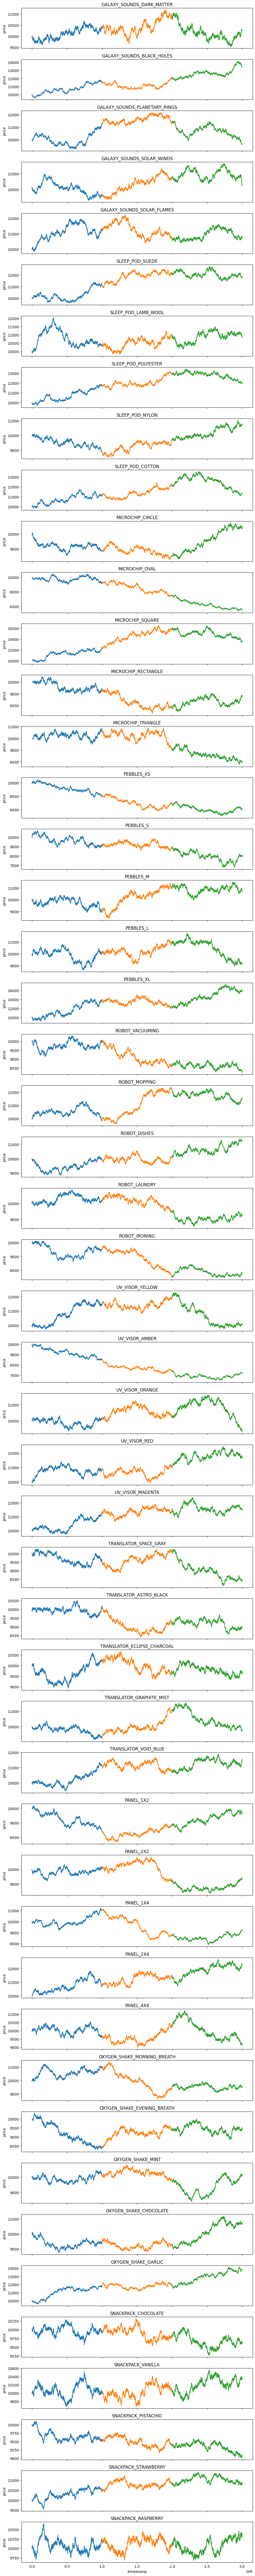

In [11]:
fig, axes = plt.subplots(50, 1, figsize=(10, 100), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(prices_flat[i].index, prices_flat[i]['mid_price'])
    ax.plot(prices_flat_1[i].index + 1000000, prices_flat_1[i]['mid_price'])
    ax.plot(prices_flat_2[i].index + 2000000, prices_flat_2[i]['mid_price'])
    ax.set_title(prices_flat[i]['product'].iloc[0])
    ax.set_ylabel('price')
axes[-1].set_xlabel('timestamp')
plt.tight_layout()
plt.show()

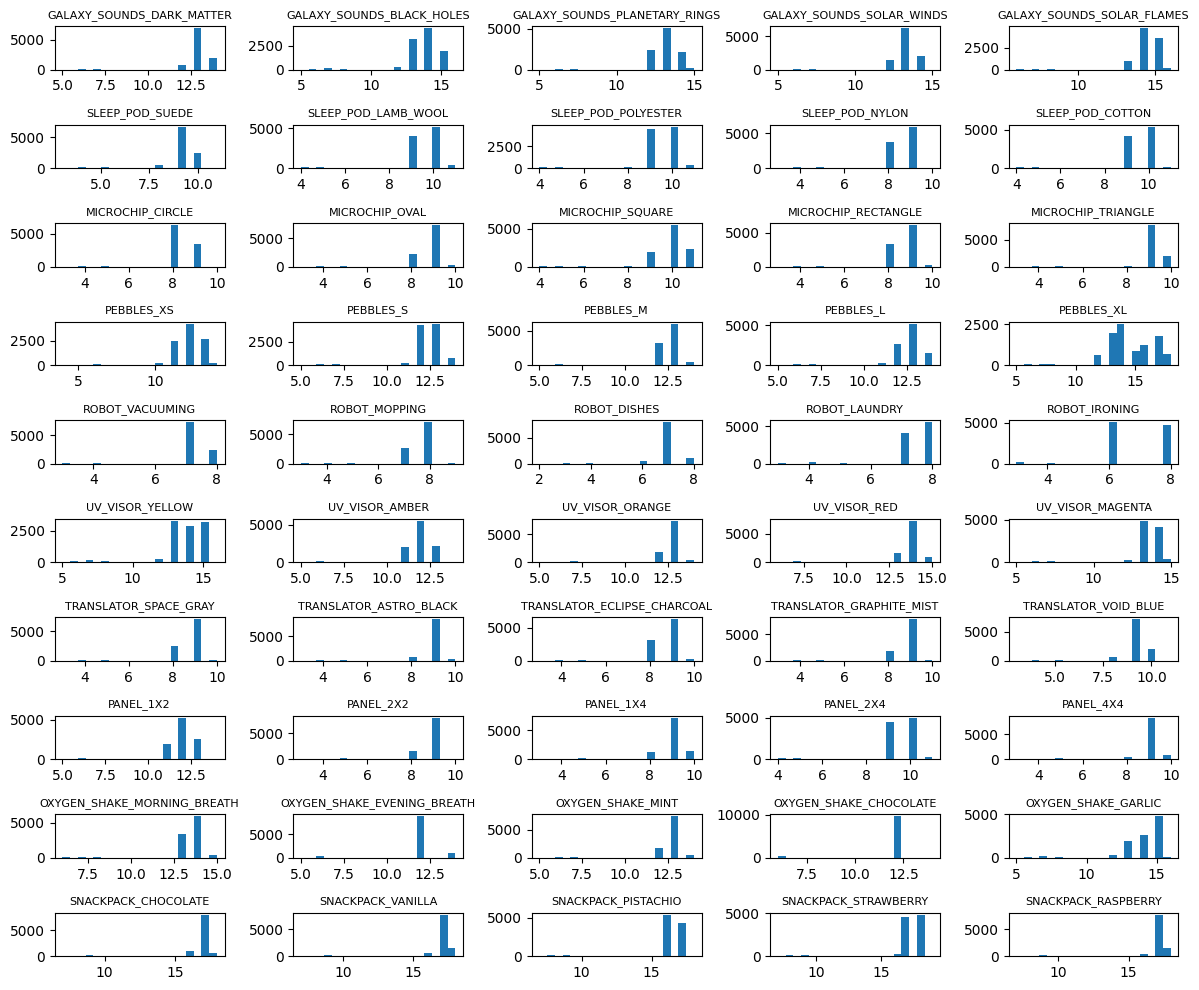

In [12]:
fig, axes = plt.subplots(10, 5, figsize=(12, 10))
for p, ax in zip(prices_flat, axes.flat):
    ax.hist(p['ask_price_1'] - p['bid_price_1'], bins=20)
    ax.set_title(p.iloc[0]['product'], fontsize=8)
plt.tight_layout()
plt.show()

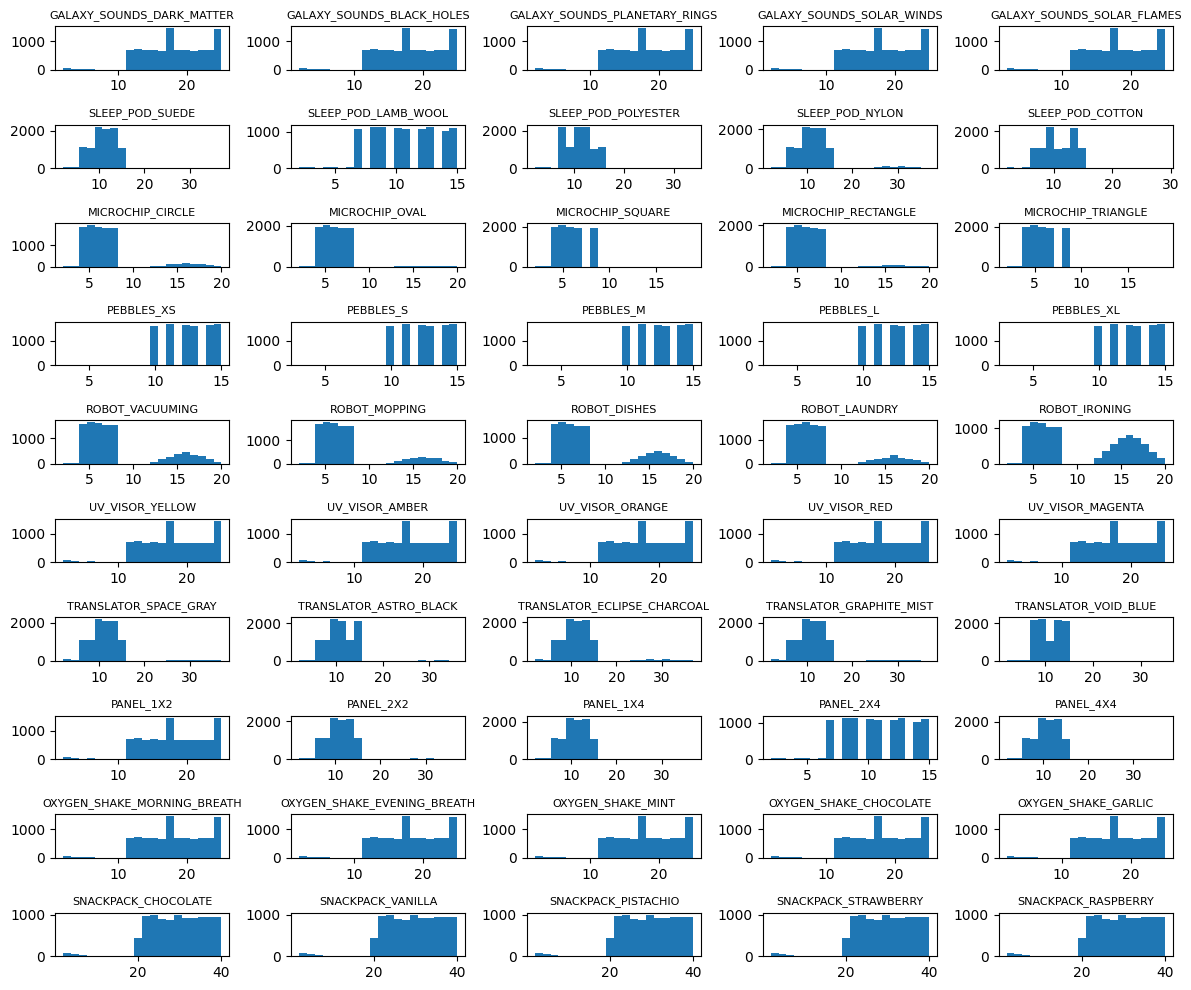

In [13]:
fig, axes = plt.subplots(10, 5, figsize=(12, 10))
for p, ax in zip(prices_flat, axes.flat):
    ax.hist(p['bid_volume_1'], bins=20)
    ax.set_title(p.iloc[0]['product'], fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
print(f"{"Product":<33}{"Spread":<10}{"Naive RMSE":<15}{"AR(1) RMSE":<15}{"AR a":<10}{"AR b":<10}{"Corr Matrix":^30}\n")
for i in range(len(prices)):
    mids = [p['mid_price'].values for p in prices[i]]
    corr_mat = np.corrcoef(mids).round(2)
    for j in range(len(prices[i])):
        train_logr = np.log(prices[i][j]['mid_price']).diff().dropna()
        test_logr = np.log(prices_1[i][j]['mid_price']).diff().dropna()
        true = test_logr[1:].to_numpy()
        naive_pred = test_logr[:-1].to_numpy()
        naive_err = true - naive_pred
        naive_rmse = np.mean(naive_err ** 2) ** 0.5
        coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
        a, b = coeffs
        pred = test_logr[:-1].to_numpy() * a
        err = true - pred
        rmse = np.mean(err ** 2) ** 0.5
        print(f"{prices[i][j]['product'].iloc[0]:<33}{(prices[i][j]['ask_price_1'] - prices[i][j]['bid_price_1']).median():<10}",
             f"{round(naive_rmse, 4):<15}{round(rmse, 4):<15}{round(a, 2):<10}{round(b, 2):<10}{str(corr_mat[j]):^30}")
    print()

Product                          Spread    Naive RMSE     AR(1) RMSE     AR a      AR b               Corr Matrix          

GALAXY_SOUNDS_DARK_MATTER        13.0       0.0014         0.001          0.0       0.0       [ 1.    0.75 -0.01 -0.63  0.64]
GALAXY_SOUNDS_BLACK_HOLES        14.0       0.0014         0.001          -0.02     0.0       [ 0.75  1.    0.32 -0.59  0.43]
GALAXY_SOUNDS_PLANETARY_RINGS    13.0       0.0014         0.001          -0.0      0.0       [-0.01  0.32  1.   -0.38 -0.51]
GALAXY_SOUNDS_SOLAR_WINDS        13.0       0.0014         0.001          -0.01     -0.0      [-0.63 -0.59 -0.38  1.   -0.14]
GALAXY_SOUNDS_SOLAR_FLAMES       14.0       0.0014         0.001          -0.02     0.0       [ 0.64  0.43 -0.51 -0.14  1.  ]

SLEEP_POD_SUEDE                  9.0        0.0014         0.001          -0.0      0.0       [ 1.   -0.23  0.6  -0.49  0.37]
SLEEP_POD_LAMB_WOOL              10.0       0.0014         0.001          -0.01     0.0       [-0.23  1.   -0.4   0.23

In [68]:
for i in range(len(prices)):
    for j in range(len(prices[i])):
        print(f"{prices[i][j]['product'].iloc[0]:<30}{round(prices[i][j]['mid_price'].std() / prices[i][j]['mid_price'].mean(), 4):<10}")
    print()

GALAXY_SOUNDS_DARK_MATTER     0.0247    
GALAXY_SOUNDS_BLACK_HOLES     0.0523    
GALAXY_SOUNDS_PLANETARY_RINGS 0.048     
GALAXY_SOUNDS_SOLAR_WINDS     0.0372    
GALAXY_SOUNDS_SOLAR_FLAMES    0.0448    

SLEEP_POD_SUEDE               0.0469    
SLEEP_POD_LAMB_WOOL           0.0447    
SLEEP_POD_POLYESTER           0.0525    
SLEEP_POD_NYLON               0.0287    
SLEEP_POD_COTTON              0.0412    

MICROCHIP_CIRCLE              0.0252    
MICROCHIP_OVAL                0.0314    
MICROCHIP_SQUARE              0.0622    
MICROCHIP_RECTANGLE           0.0395    
MICROCHIP_TRIANGLE            0.0247    

PEBBLES_XS                    0.0675    
PEBBLES_S                     0.0469    
PEBBLES_M                     0.034     
PEBBLES_L                     0.0513    
PEBBLES_XL                    0.1241    

ROBOT_VACUUMING               0.0245    
ROBOT_MOPPING                 0.0279    
ROBOT_DISHES                  0.0341    
ROBOT_LAUNDRY                 0.0252    
ROBOT_IRONIN

# Spreads

In [15]:
prices_train = []
for i in range(len(prices)):
    lis = []
    for p, p_1 in zip(prices[i], prices_1[i]):
        p_1.index += 1_000_000
        lis.append(pd.concat([p, p_1]))
    prices_train.append(lis)

In [16]:
prices_test = prices_2


--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_WINDS', 'GALAXY_SOUNDS_SOLAR_FLAMES']
              Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue   Half_Life
0  (1, -1, 0, -1, -1)           1                4    0.010618  827.227849
1   (2, -1, 0, -1, 0)           2                4    0.002563  468.922722
2  (2, -1, 0, -1, -1)           2                5    0.002702  567.051459
3  (2, -1, 0, -2, -2)           2                7    0.009550  775.574227
4  (2, -1, 0, -2, -1)           2                6    0.009809  674.874295
5  (2, -2, 0, -2, -2)           2                8    0.010618  827.227849
6  (2, -2, 0, -1, -1)           2                6    0.012475  756.202759
7    (2, -1, 0, 0, 0)           2                3    0.015392  648.848865
8  (2, -2, 0, -2, -1)           2                7    0.016388  746.516028
9  (2, -1, 0, -1, -2)           2          

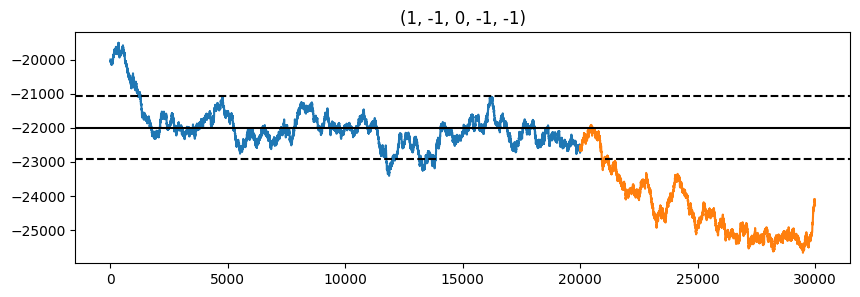

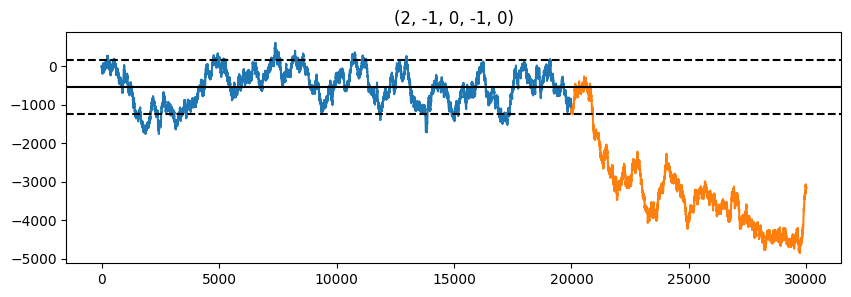

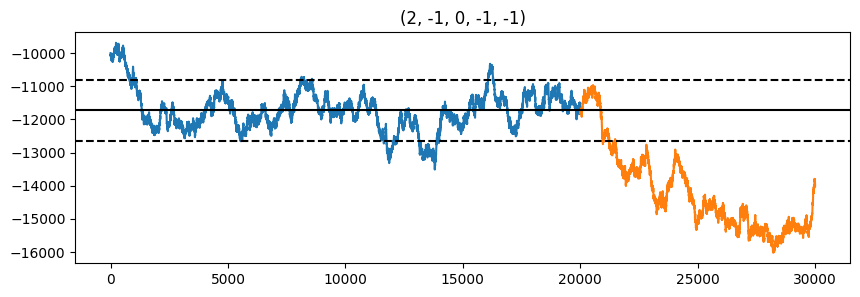

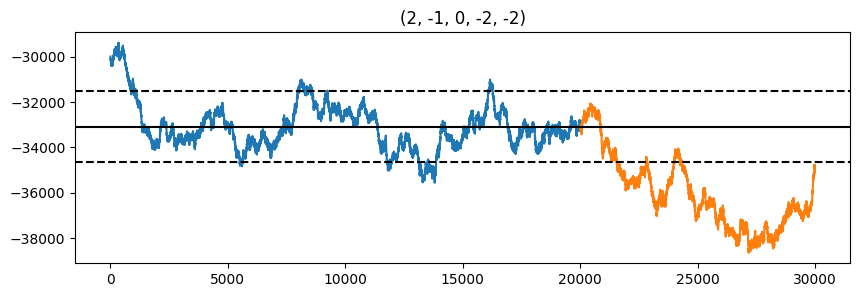

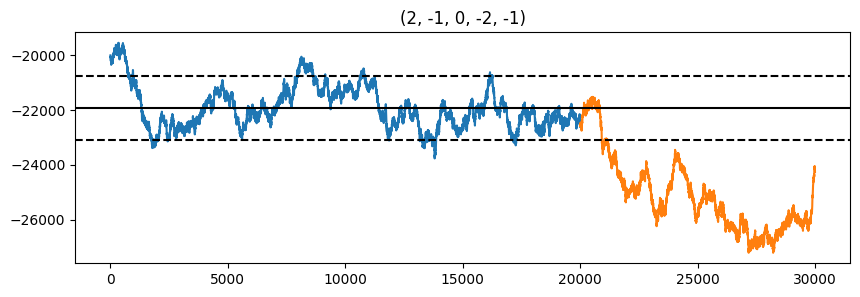

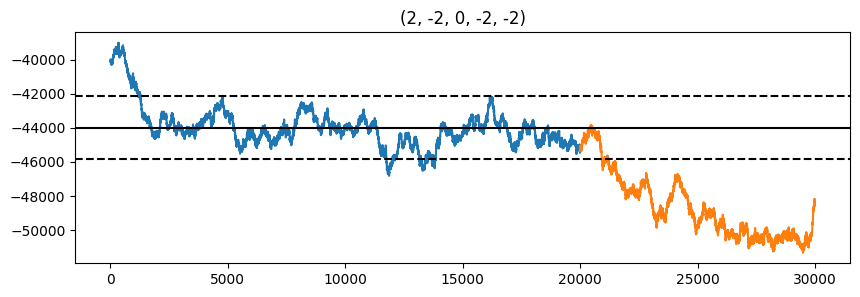

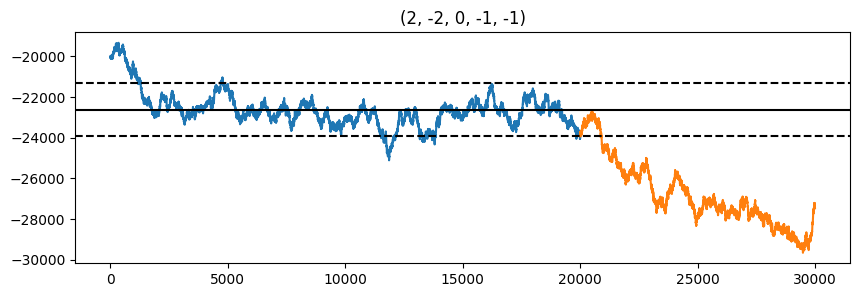

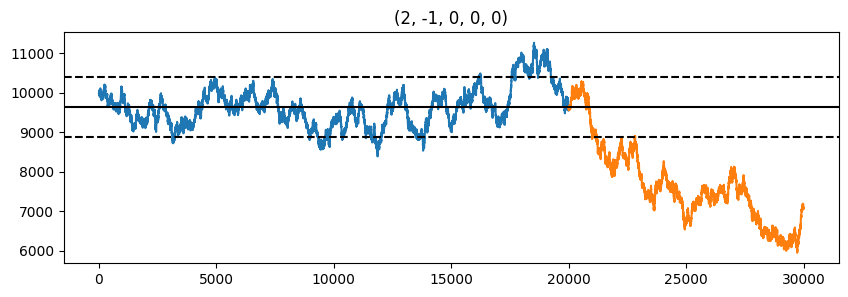

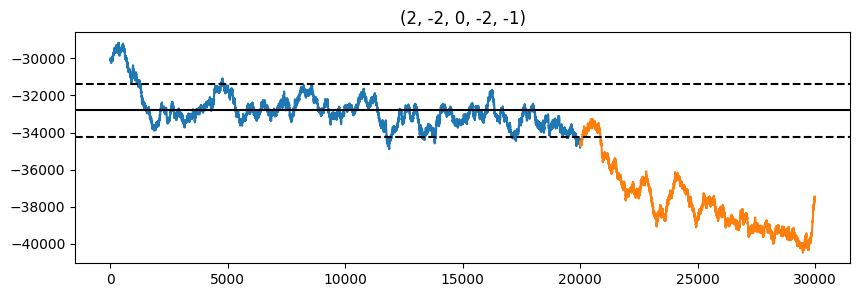

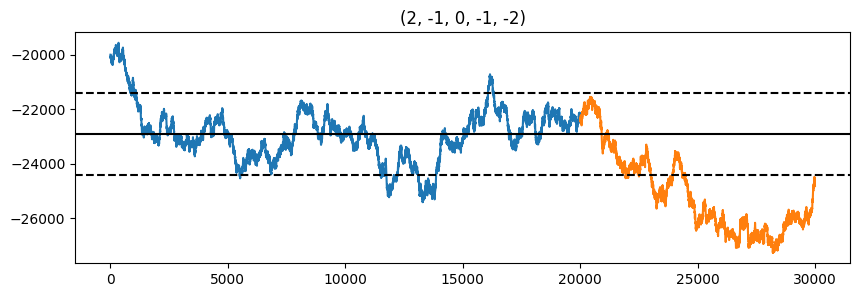

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['SLEEP_POD_SUEDE', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_NYLON', 'SLEEP_POD_COTTON']
              Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue    Half_Life
0    (0, 1, 0, -1, 0)           1                2    0.010326   823.240839
1    (0, 1, 0, -1, 1)           1                3    0.022521  1155.353677
2   (1, -1, -1, 1, 0)           1                4    0.043320  1015.423664
3    (0, 2, 0, -2, 1)           2                5    0.004827   855.117330
4   (0, 1, -1, -2, 2)           2                6    0.005317   691.311182
5   (0, 2, -1, -2, 2)           2                7    0.007344   758.576721
6   (1, 1, -2, -2, 2)           2                8    0.009031   676.349524
7    (0, 1, 0, -2, 0)           2                3    0.009667   795.708832
8    (0, 

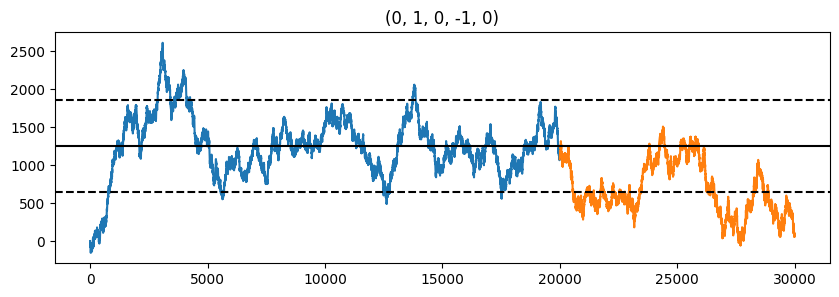

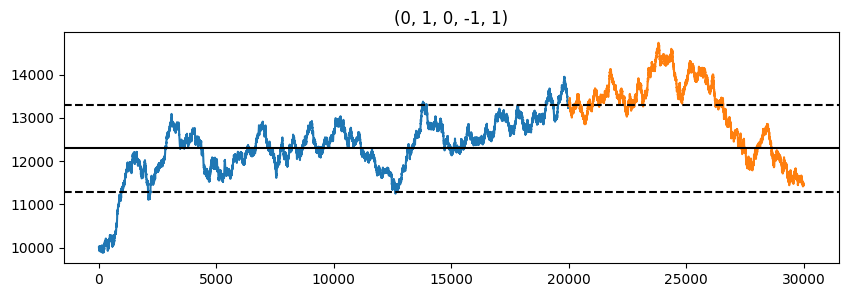

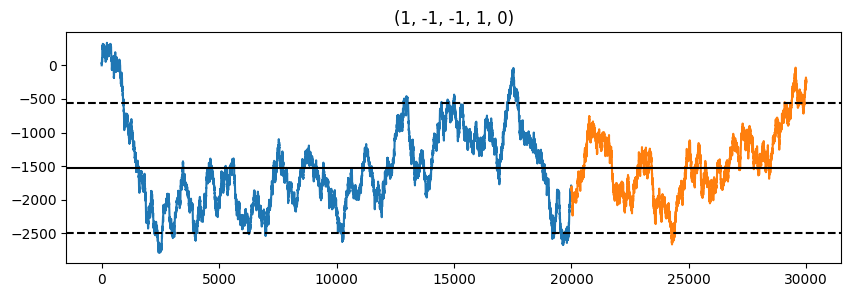

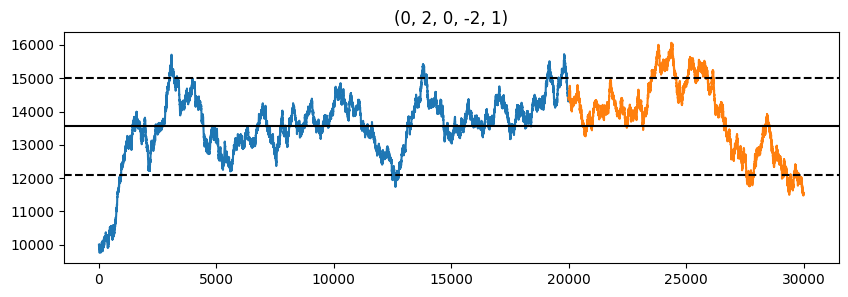

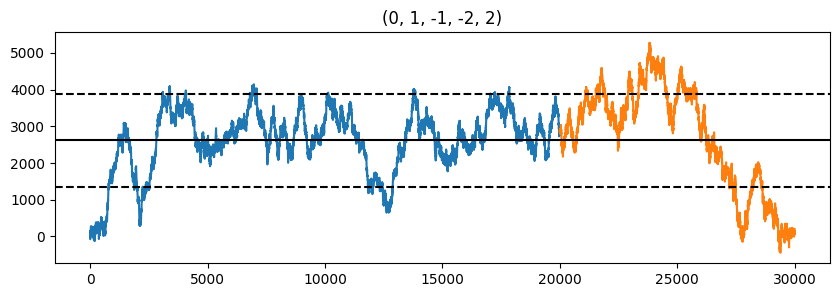

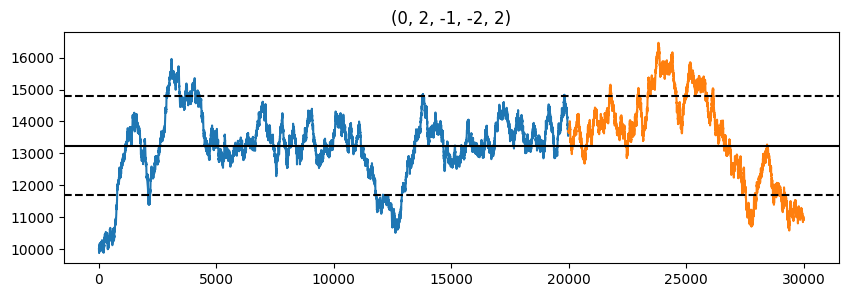

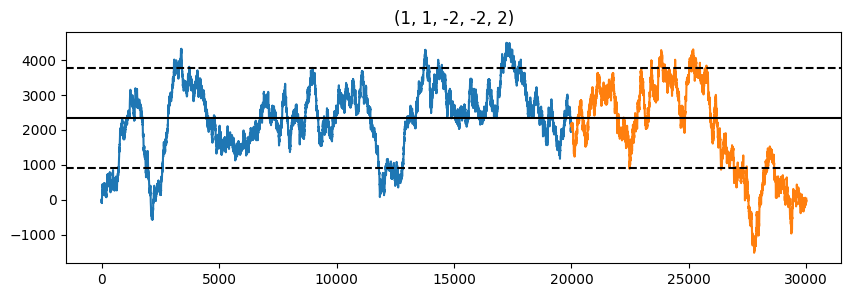

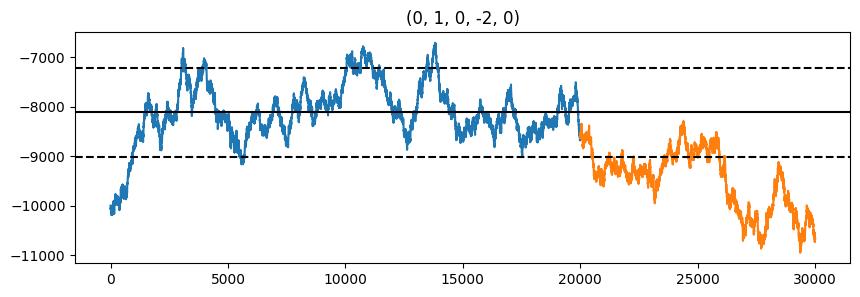

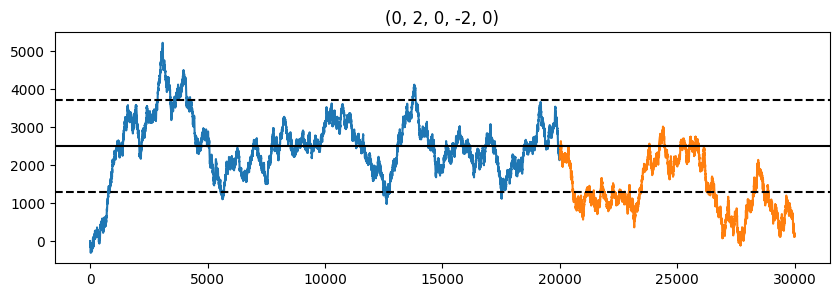

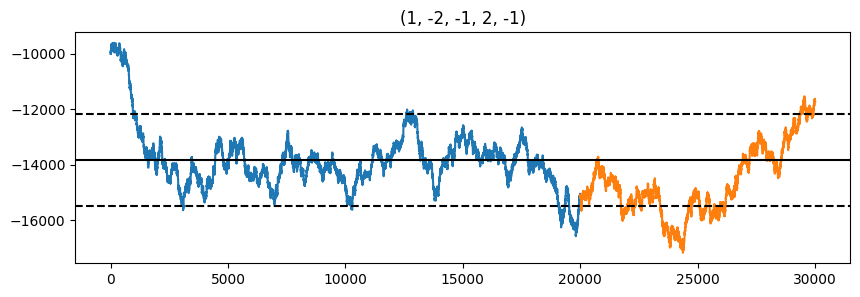

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_SQUARE', 'MICROCHIP_RECTANGLE', 'MICROCHIP_TRIANGLE']
               Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue    Half_Life
0    (1, 1, 0, -1, -1)           1                4    0.005011   558.274782
1    (0, 1, 0, -1, -1)           1                3    0.005751   519.398849
2     (1, -1, 0, 1, 0)           1                3    0.007593   645.621234
3     (1, 0, 0, 0, -1)           1                2    0.010230   675.938417
4     (0, 1, 0, -1, 0)           1                2    0.016917   623.416299
5     (1, -1, 0, 1, 1)           1                4    0.017435   642.811355
6  (1, -1, -1, -1, -1)           1                5    0.020458   822.078770
7      (1, 0, 0, 0, 0)           1                1    0.025523  1004.593791
8

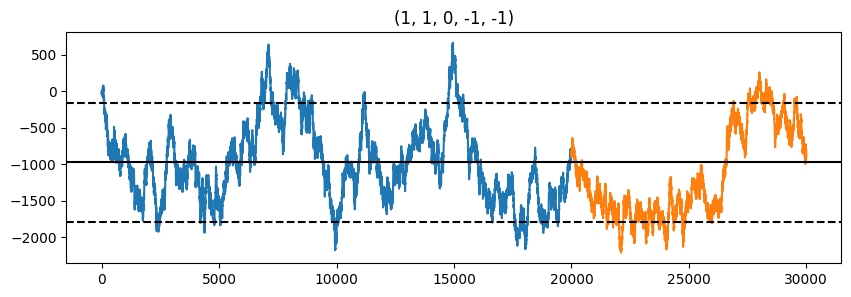

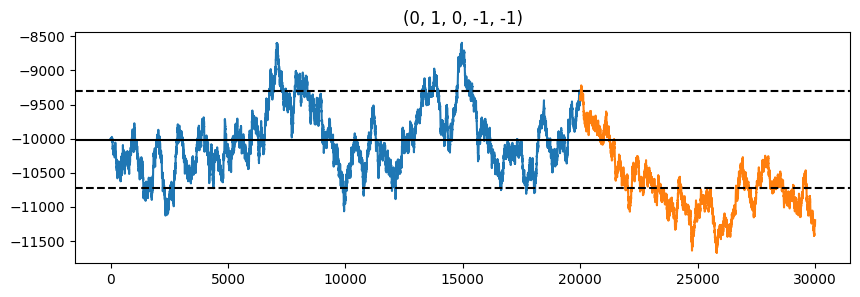

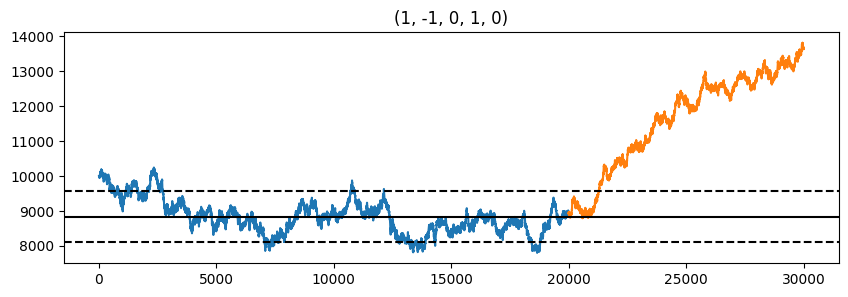

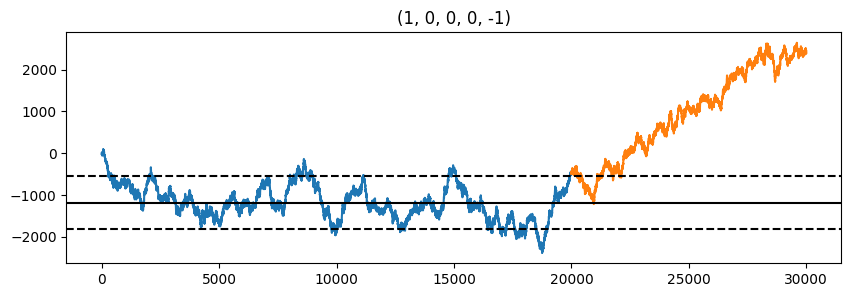

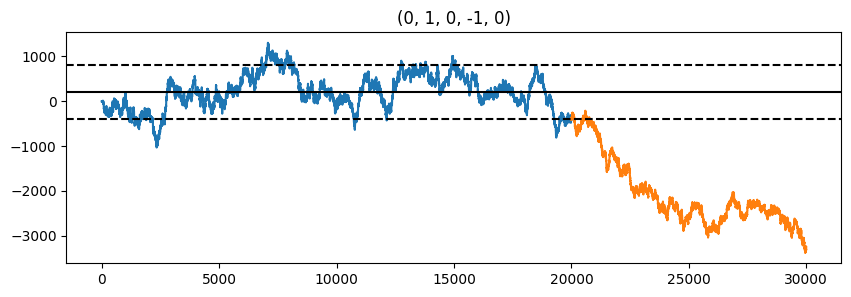

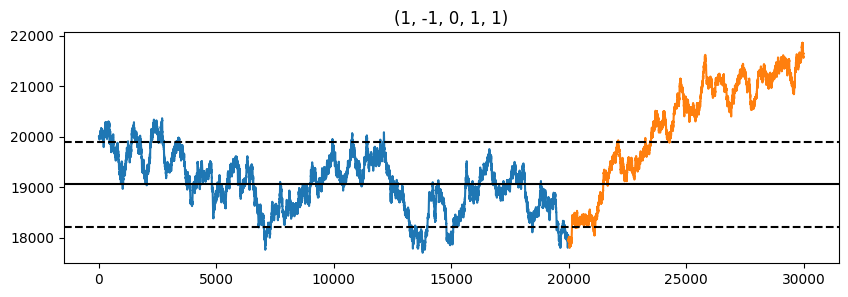

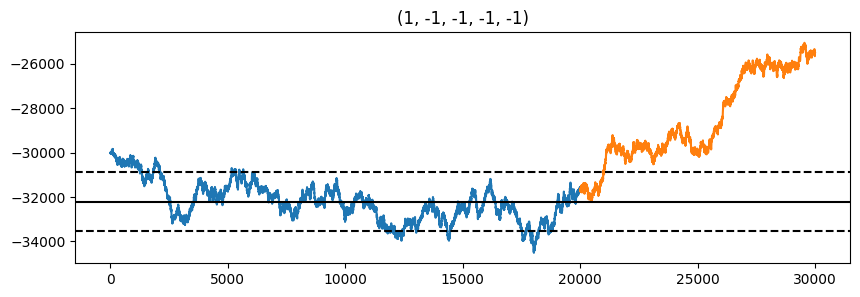

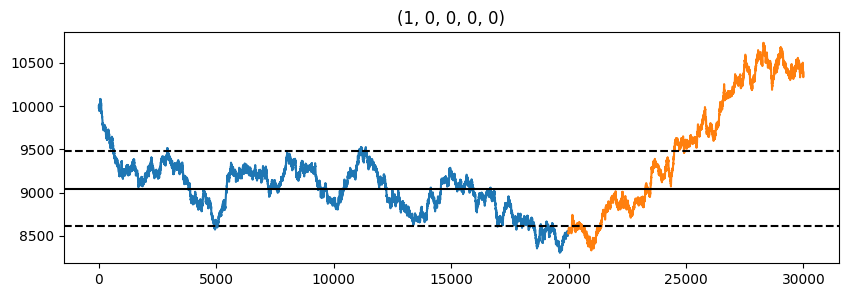

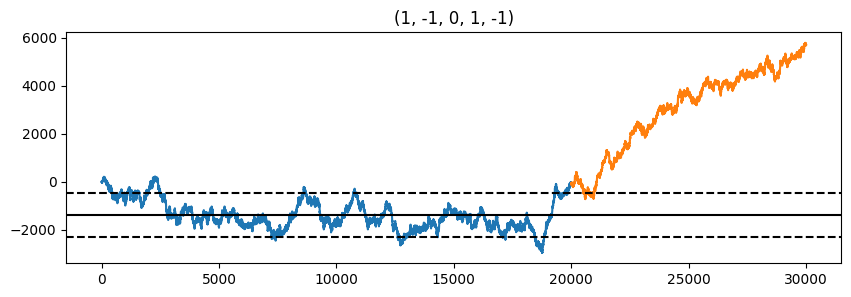

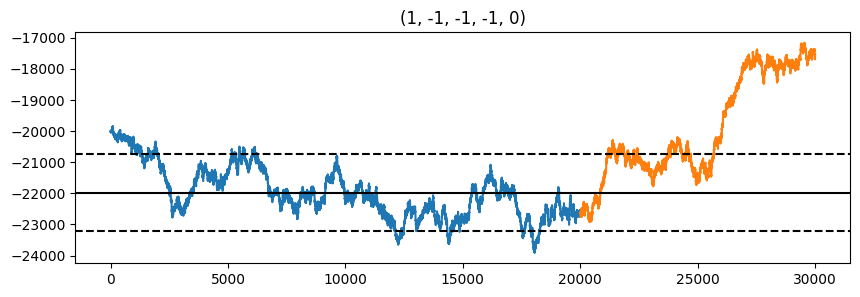

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['PEBBLES_XS', 'PEBBLES_S', 'PEBBLES_M', 'PEBBLES_L', 'PEBBLES_XL']
           Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue   Half_Life
0  (1, 1, 1, 1, 1)           1                5    0.000000    0.702347
1  (2, 2, 2, 2, 2)           2               10    0.000000    0.702347
2  (3, 3, 3, 3, 3)           3               15    0.000000    0.702347
3  (4, 4, 4, 4, 4)           4               20    0.000000    0.702347
4  (5, 5, 5, 5, 5)           5               25    0.000000    0.702347
5  (5, 4, 5, 5, 5)           5               24    0.039702  447.859537
6  (6, 6, 6, 6, 6)           6               30    0.000000    0.702347
7  (6, 5, 6, 6, 6)           6               29    0.021397  351.033110
8  (5, 6, 5, 5, 5)           6               26    0.032533  410.300348
9  (7, 7, 

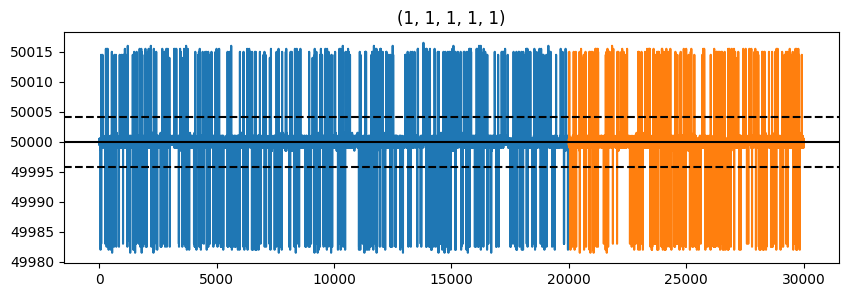

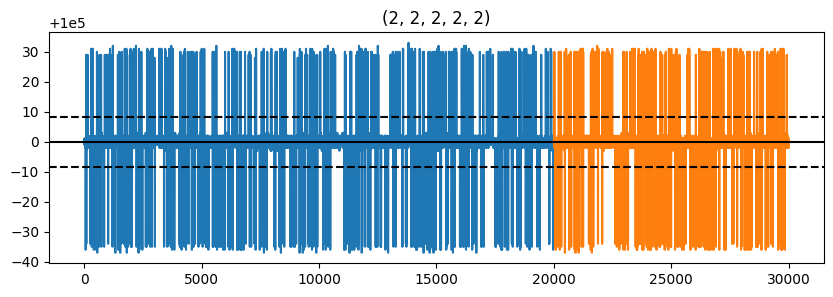

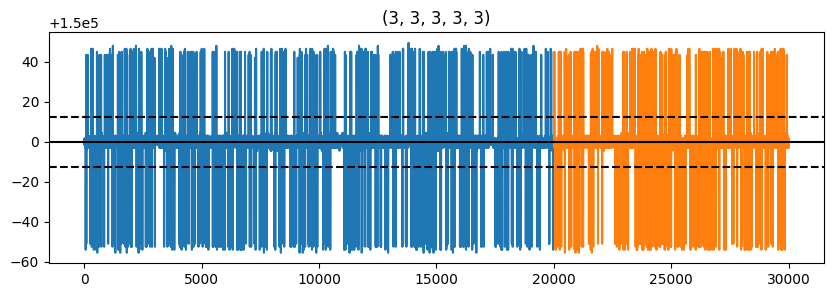

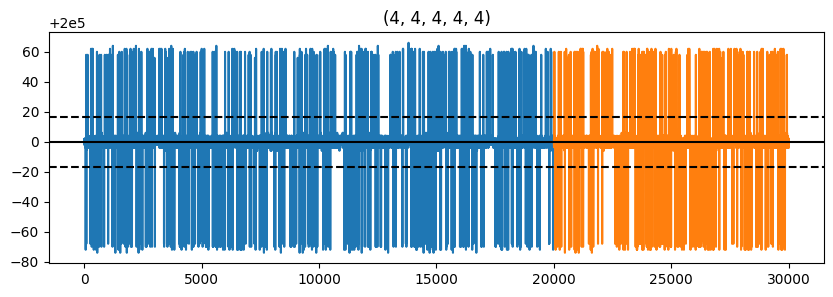

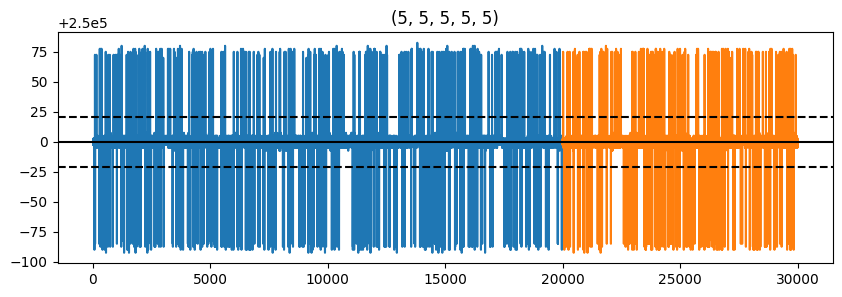

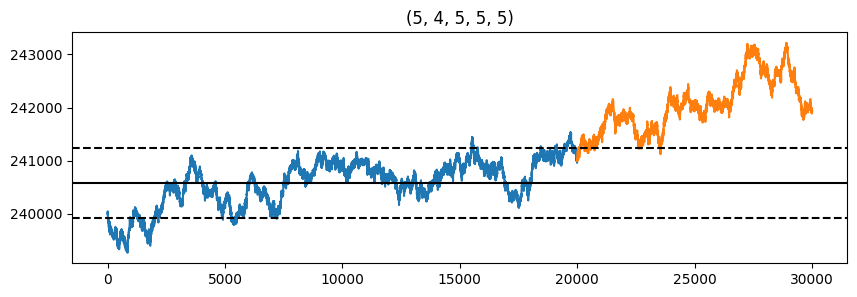

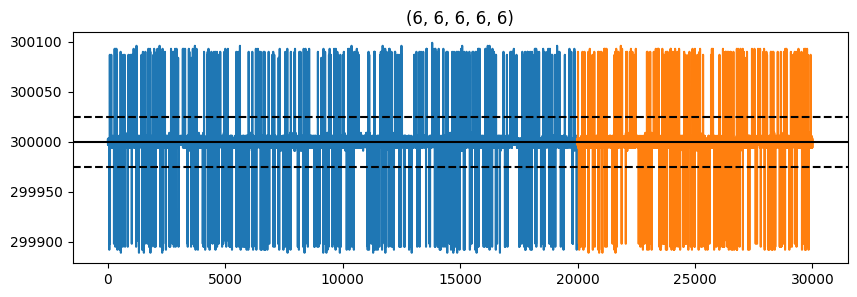

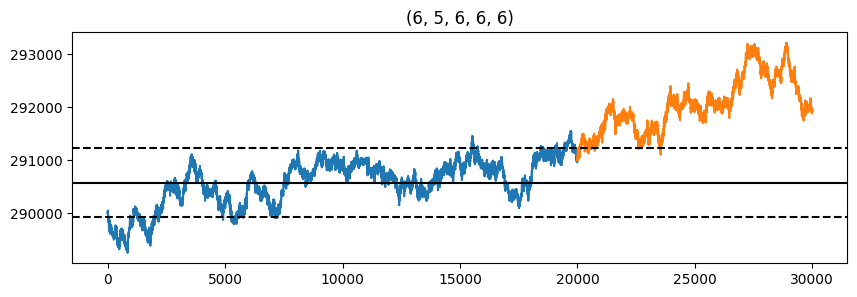

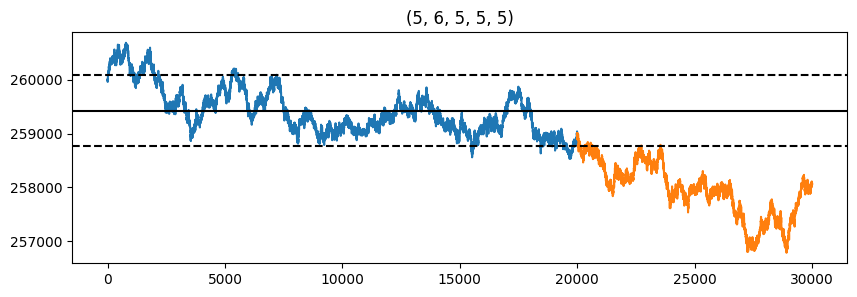

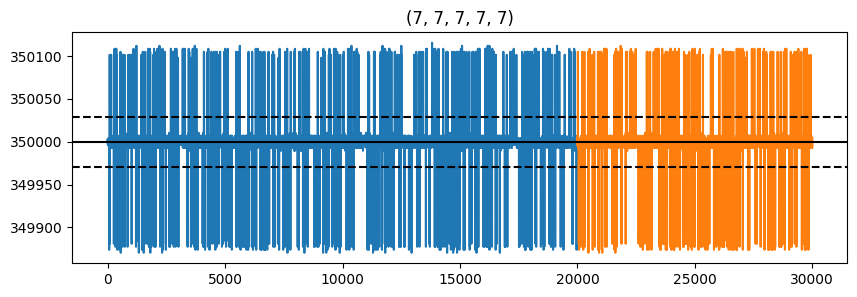

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_DISHES', 'ROBOT_LAUNDRY', 'ROBOT_IRONING']
              Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue   Half_Life
0    (1, 0, 1, -1, 0)           1                3    0.021004  805.879208
1    (1, 0, 0, -1, 0)           1                2    0.034848  888.619559
2    (1, 1, 1, -1, 1)           1                5    0.034927  828.051217
3     (1, 1, 1, 0, 1)           1                4    0.037877  764.087502
4     (0, 1, 0, 1, 1)           1                3    0.038810  601.289389
5    (1, 0, 0, -2, 0)           2                3    0.009644  620.490562
6  (1, -1, 0, -2, -1)           2                5    0.012823  599.024442
7    (2, 0, 1, -2, 0)           2                5    0.013016  739.201417
8    (2, 1, 1, -2, 1)           2   

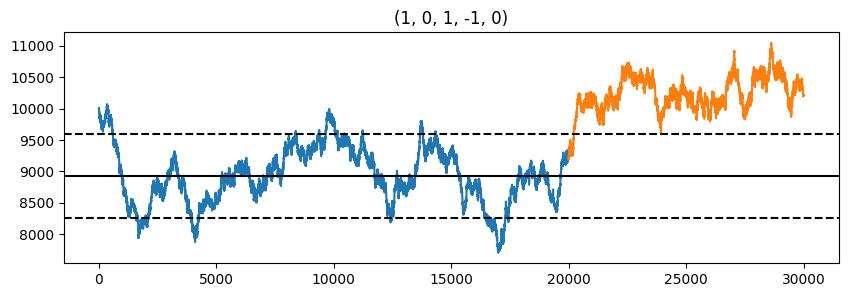

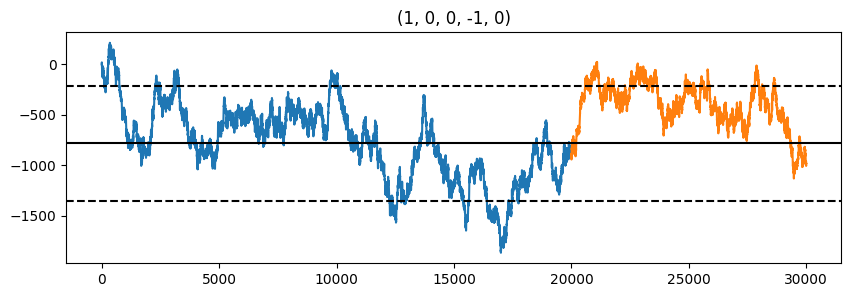

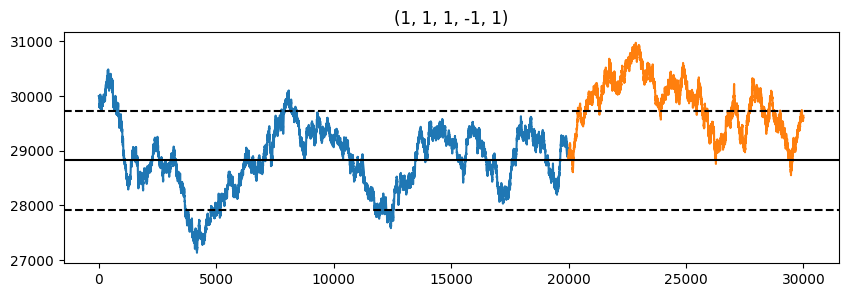

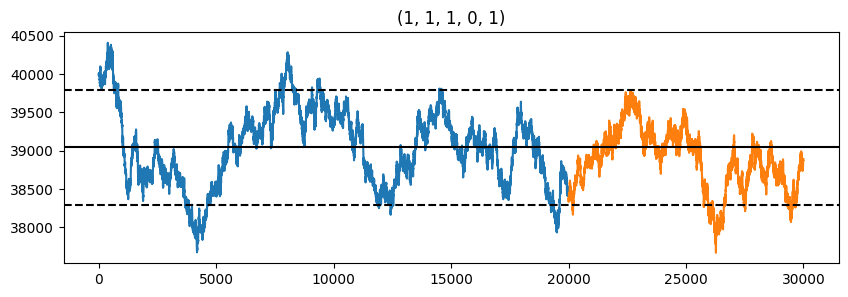

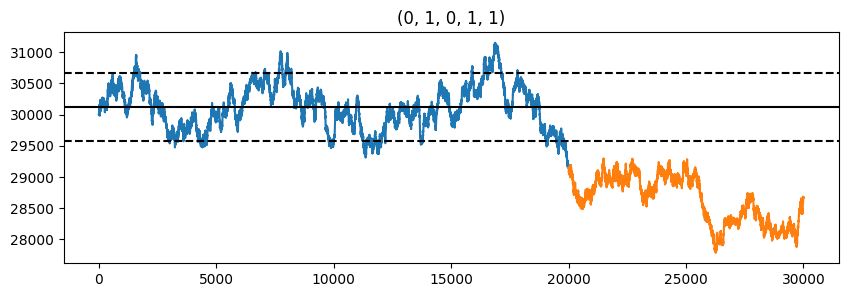

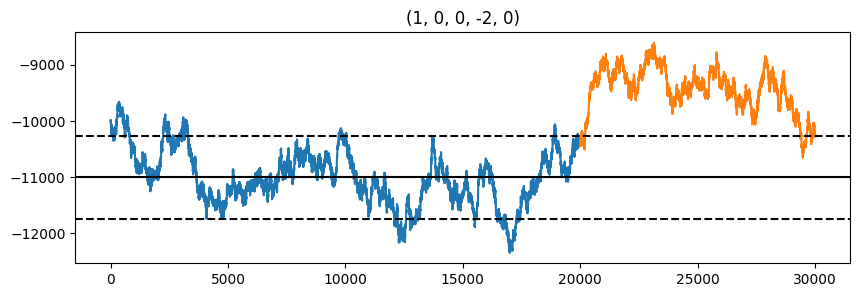

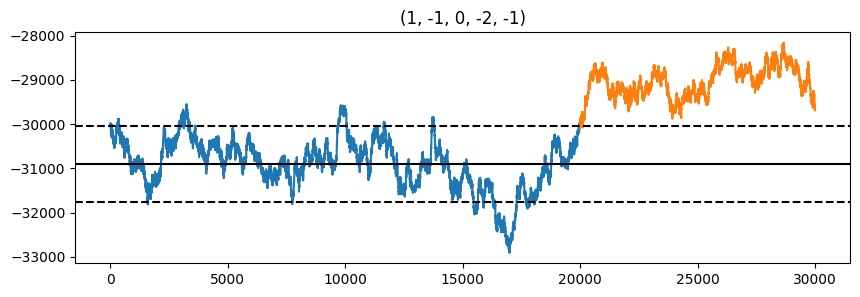

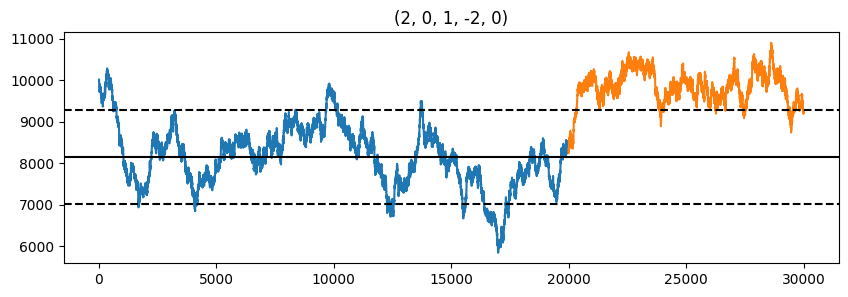

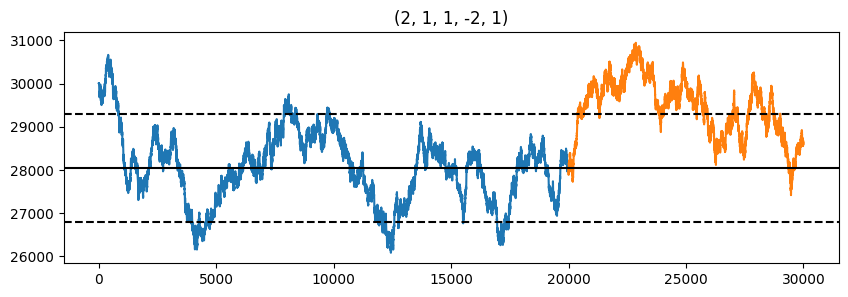

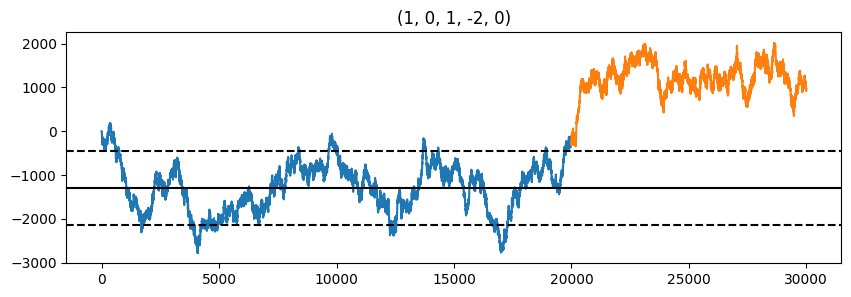

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['UV_VISOR_YELLOW', 'UV_VISOR_AMBER', 'UV_VISOR_ORANGE', 'UV_VISOR_RED', 'UV_VISOR_MAGENTA']
             Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue   Half_Life
0    (0, 1, 1, 1, 1)           1                4    0.005973  521.984817
1    (1, 1, 1, 0, 0)           1                3    0.006224  547.587507
2  (0, 0, 1, -1, -1)           1                3    0.016454  734.007382
3    (1, 1, 1, 1, 0)           1                4    0.019008  659.759879
4  (1, 0, 1, -1, -1)           1                4    0.019225  676.214245
5    (0, 1, 1, 0, 1)           1                3    0.023325  708.705392
6  (1, 0, 0, -1, -1)           1                3    0.023408  723.004479
7   (1, 0, 1, 0, -1)           1                3    0.028891  747.683129
8    (0, 0, 0, 1, 0)           1       

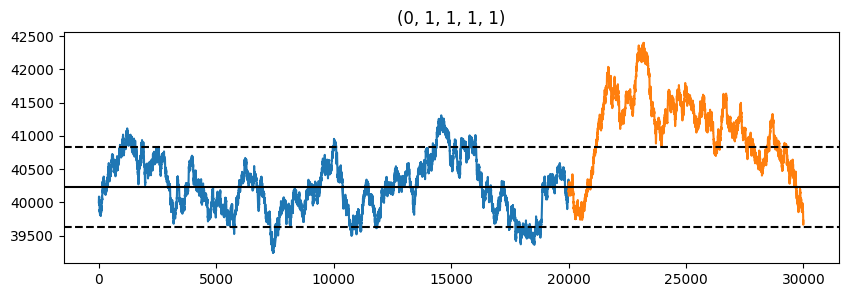

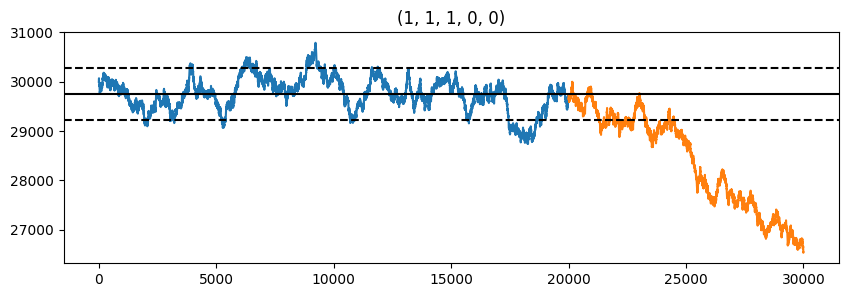

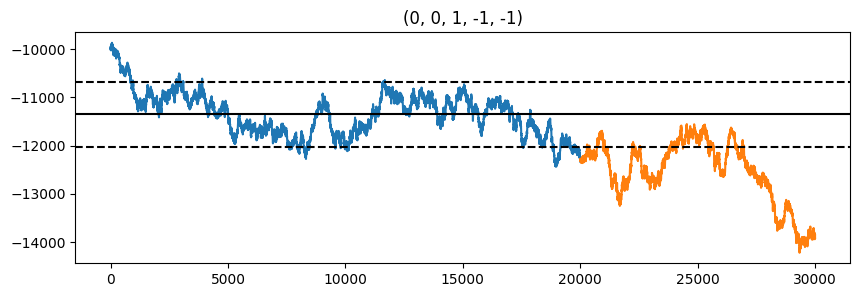

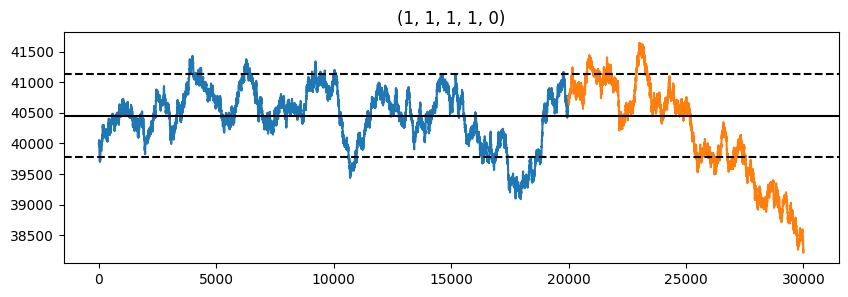

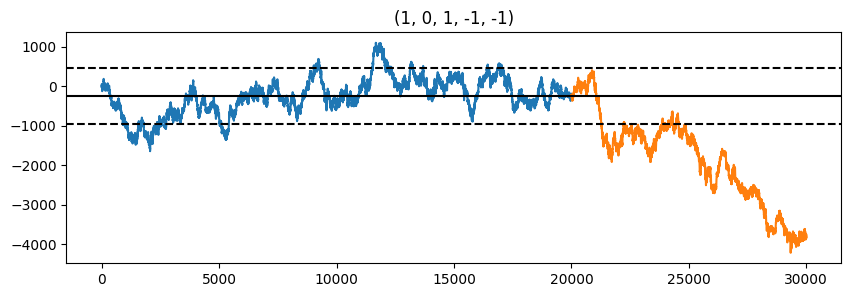

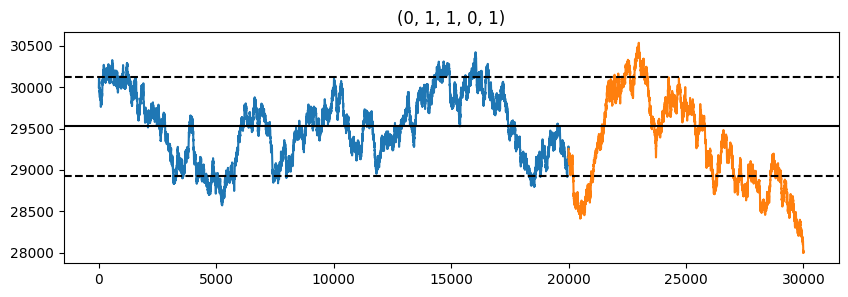

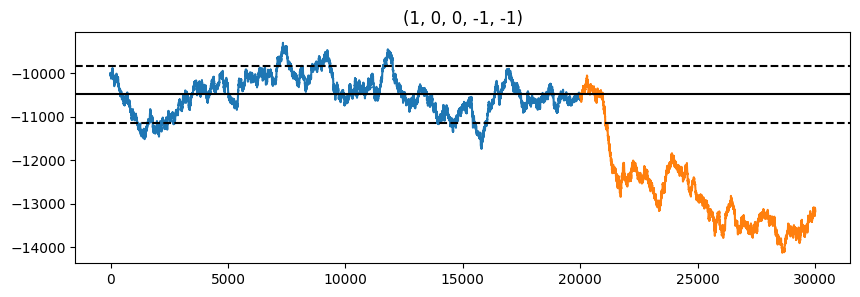

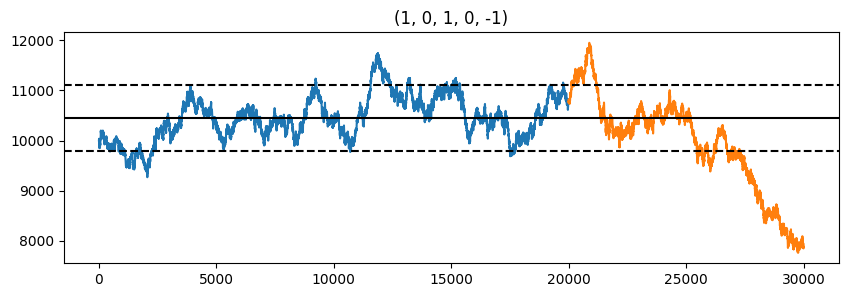

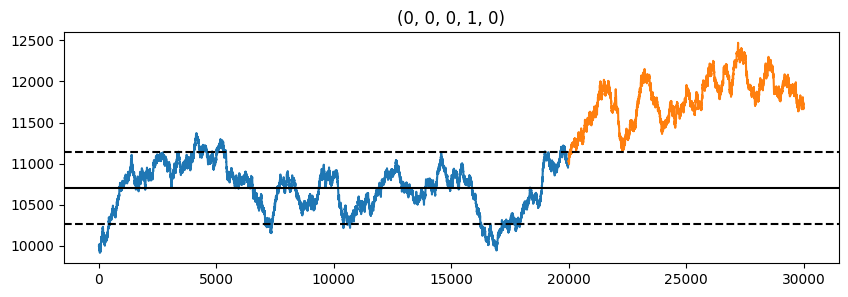

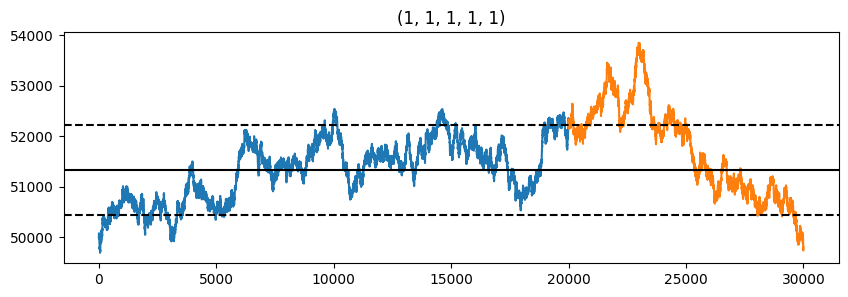

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_VOID_BLUE']
              Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue    Half_Life
0  (1, -1, 1, -1, -1)           1                5    0.036793   778.438186
1    (0, 1, -1, 0, 1)           1                3    0.038253   800.234194
2    (1, 0, 1, 0, -1)           1                3    0.047487  1017.554235
3    (1, 0, 2, 0, -1)           2                4    0.006851   635.877826
4    (2, 0, 2, 0, -1)           2                5    0.008326   655.256890
5    (0, 1, -2, 0, 2)           2                5    0.008449   613.246623
6   (1, -1, 2, 0, -2)           2                6    0.008614   633.194382
7  (1, -1, 2, -1, -2)           2                7    0

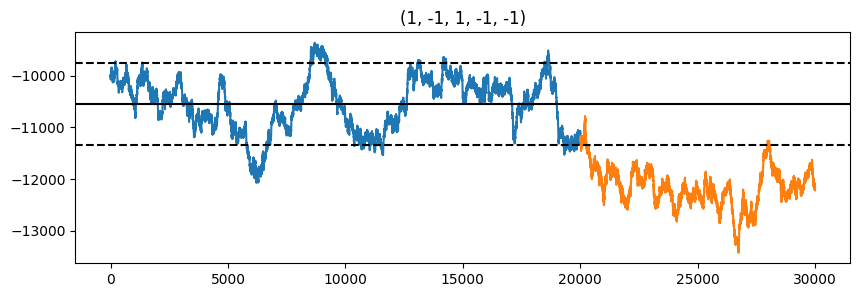

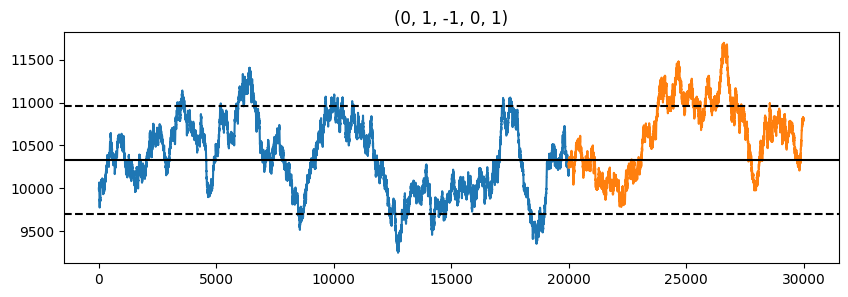

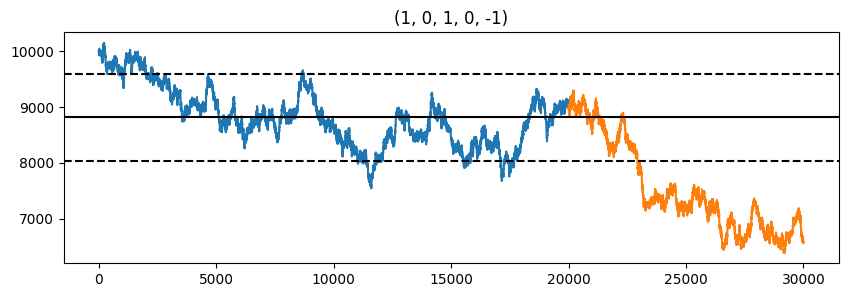

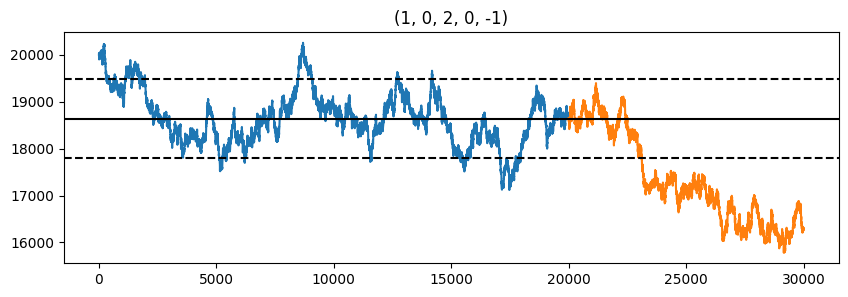

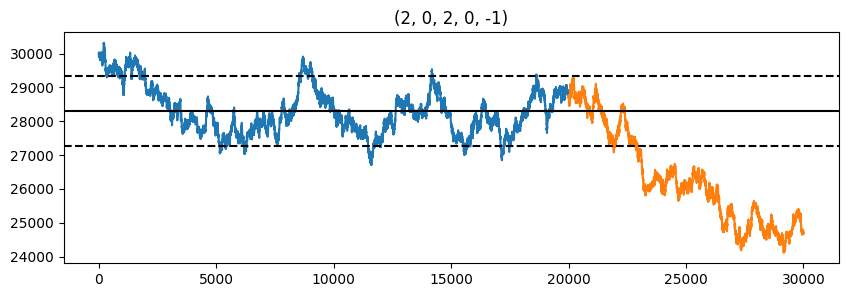

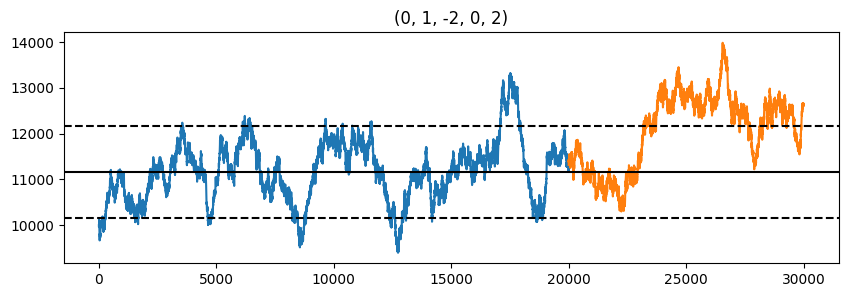

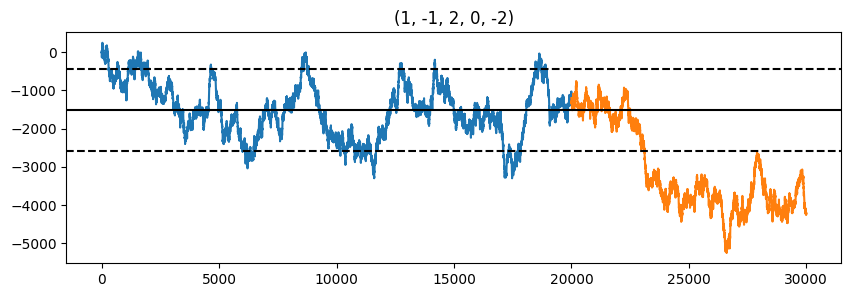

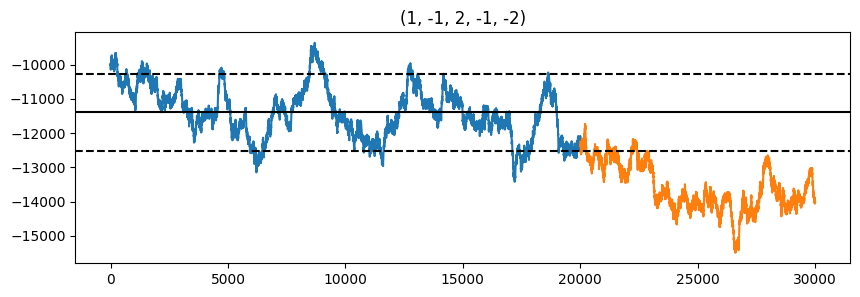

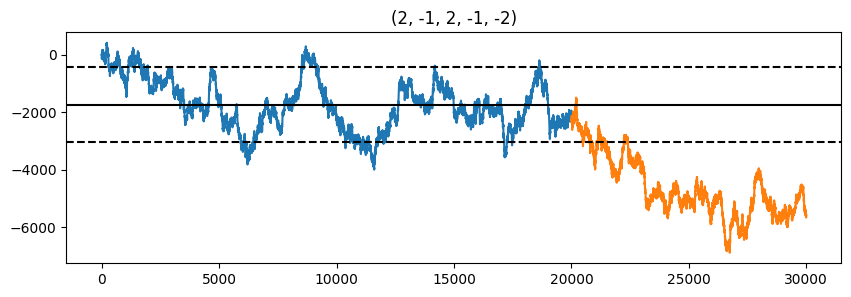

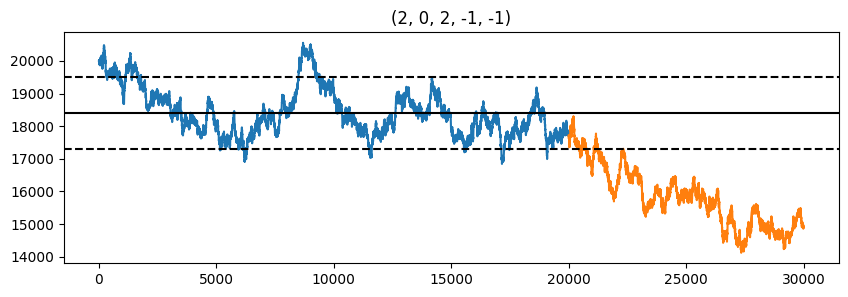

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['PANEL_1X2', 'PANEL_2X2', 'PANEL_1X4', 'PANEL_2X4', 'PANEL_4X4']
             Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue    Half_Life
0    (0, 1, 0, 0, 1)           1                2    0.006478   521.865255
1   (1, 0, 0, 0, -1)           1                2    0.042332  1027.745178
2  (1, -1, 0, 1, -2)           2                5    0.001988   448.049551
3  (1, -1, 0, 0, -2)           2                4    0.002765   504.938759
4    (0, 2, 0, 0, 2)           2                4    0.006478   521.865255
5  (1, -2, 0, 1, -2)           2                6    0.010920   552.992380
6  (1, -2, 1, 2, -2)           2                8    0.014836   647.162624
7   (0, 2, 0, -1, 2)           2                5    0.015867   667.939693
8  (2, -1, 1, 2, -2)           2                8    0.01

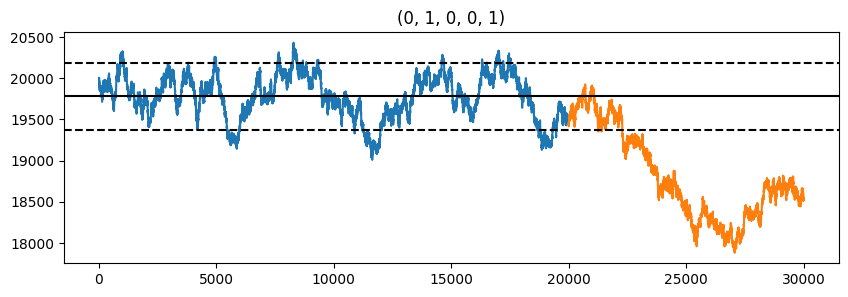

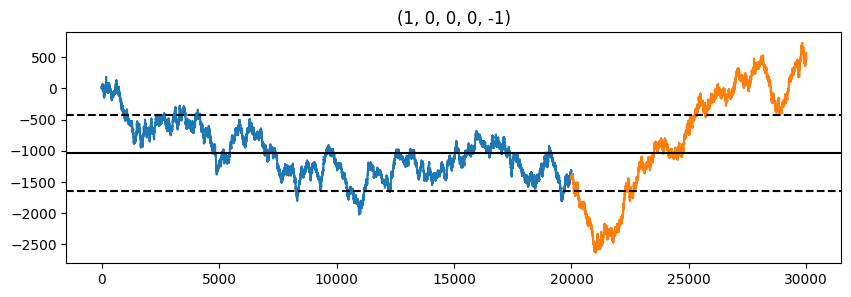

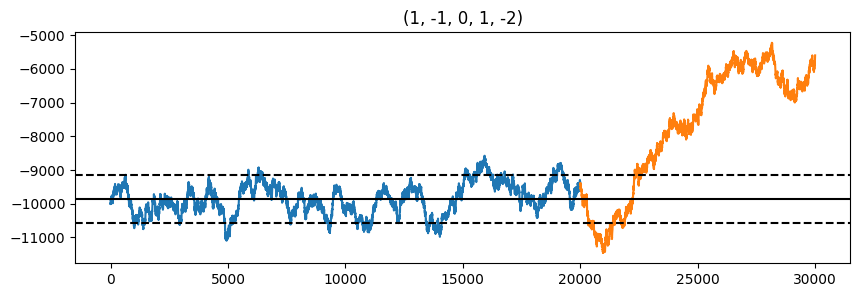

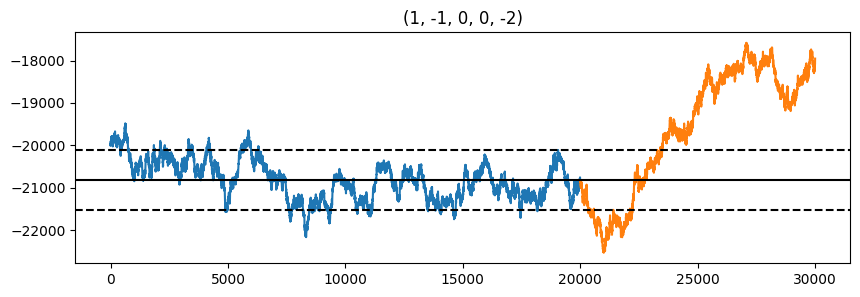

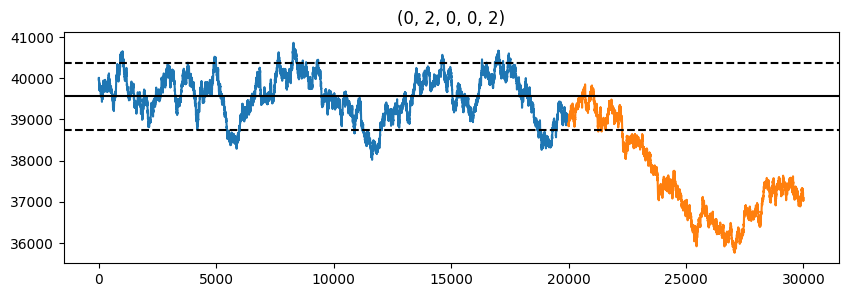

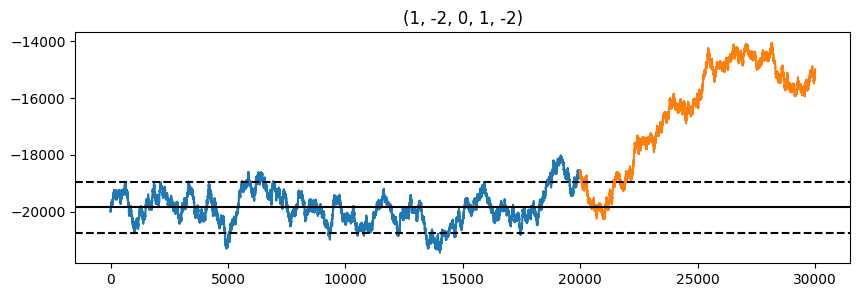

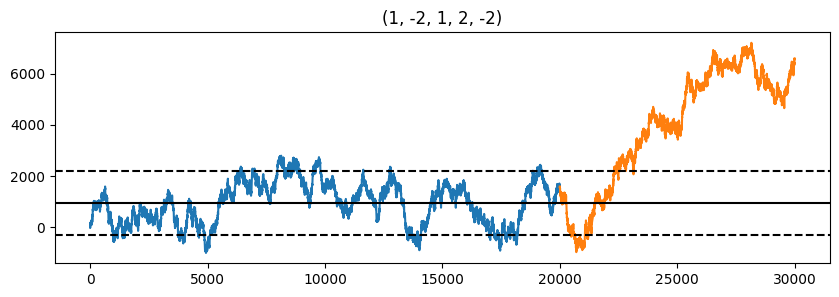

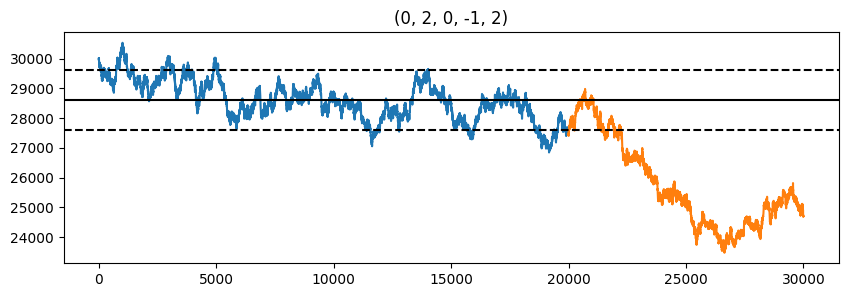

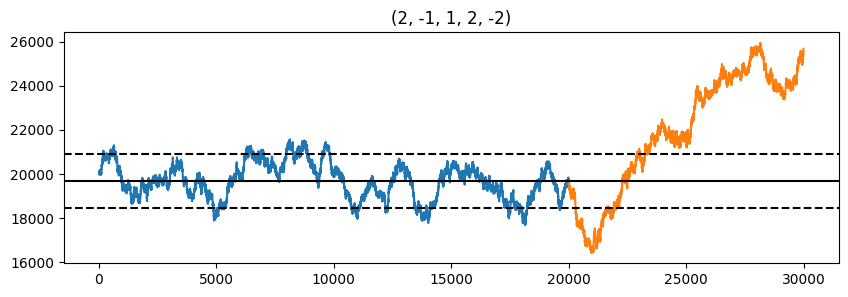

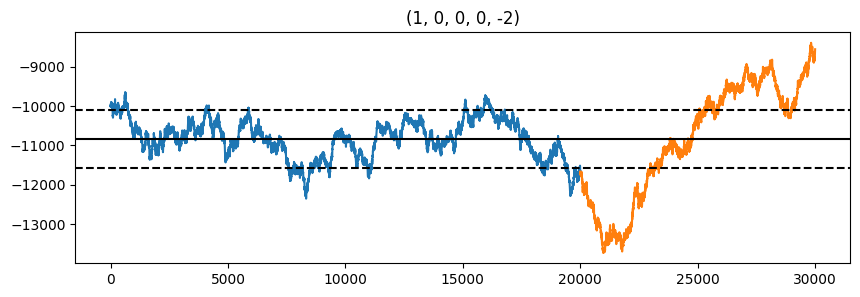

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['OXYGEN_SHAKE_MORNING_BREATH', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_GARLIC']
             Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue    Half_Life
0    (0, 0, 0, 1, 0)           1                1    0.015200   731.829883
1   (1, 1, 0, -1, 1)           1                4    0.029647   877.787156
2  (1, 1, -1, -1, 1)           1                5    0.036672   872.553791
3    (0, 0, 1, 1, 0)           1                2    0.037303   782.805733
4   (1, 1, 1, -1, 1)           1                5    0.046678   956.456398
5   (1, 0, 0, -1, 1)           1                3    0.048336  1528.641872
6    (0, 0, 0, 2, 0)           2                2    0.015200   731.829883
7    (0, 0, 1, 2, 0)           2                3    0.017089   7

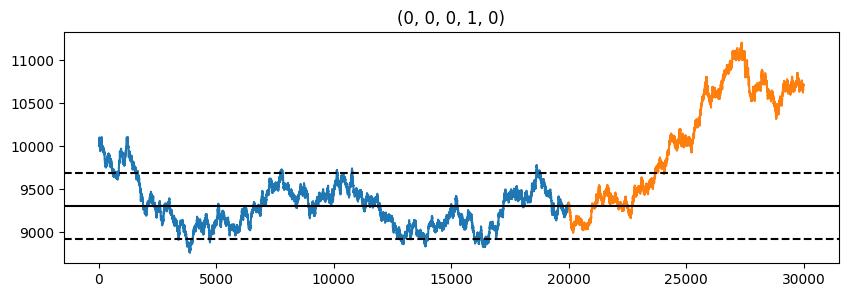

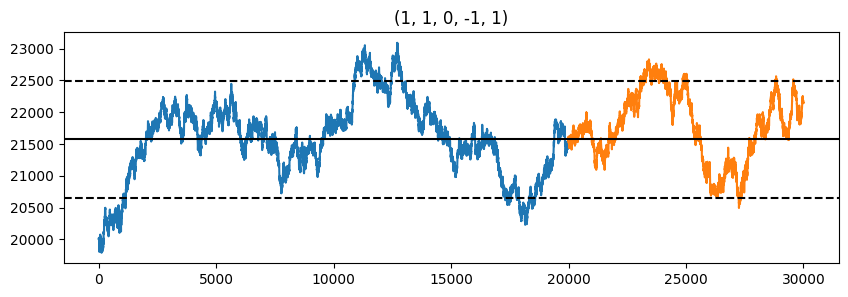

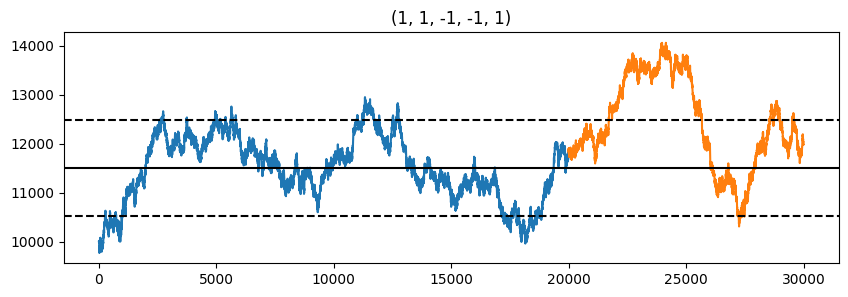

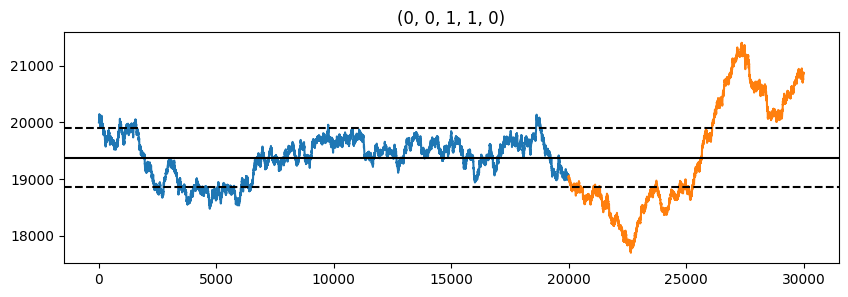

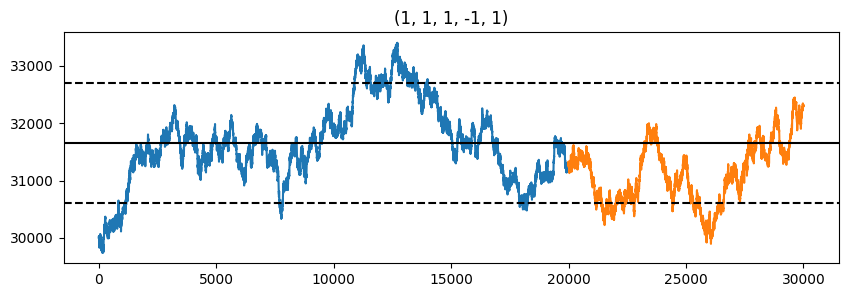

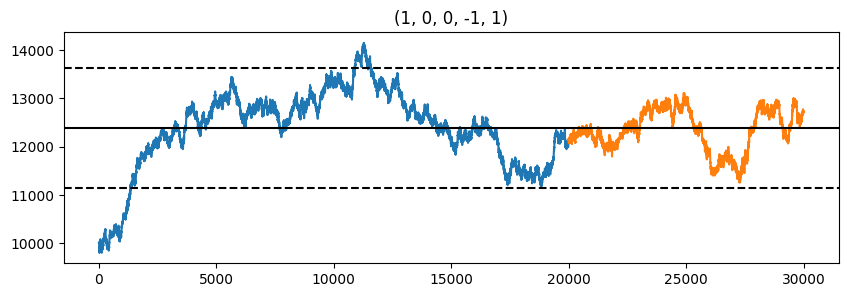

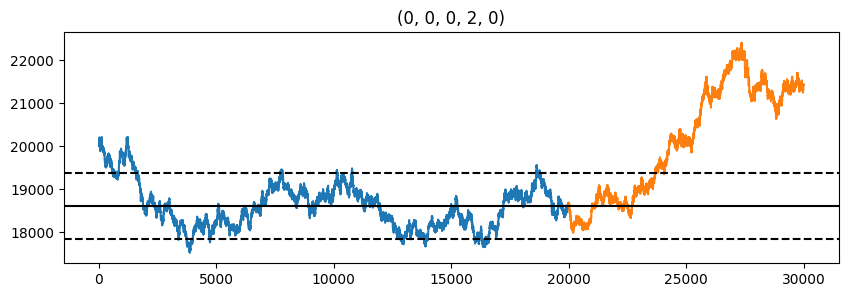

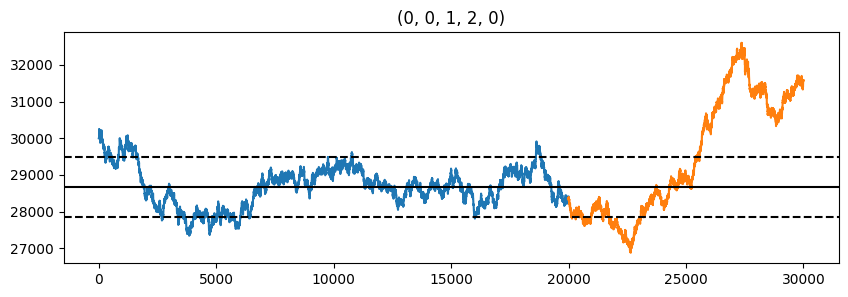

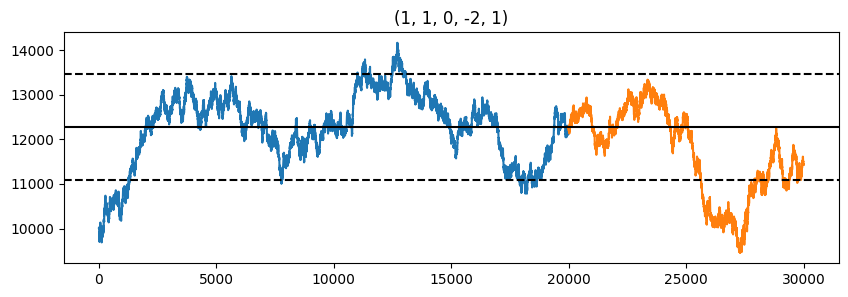

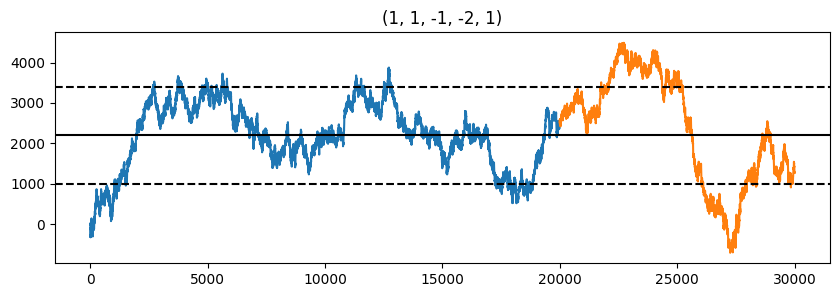

#################################################################################################################################################

--- Top 10 Smallest Tradeable Baskets ---
Asset Order: ['SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA', 'SNACKPACK_PISTACHIO', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_RASPBERRY']
            Weights  Max_Weight  Sum_Abs_Weights  ADF_PValue   Half_Life
0   (0, 0, 0, 0, 1)           1                1    0.007113  542.350127
1   (1, 1, 0, 0, 1)           1                3    0.008690  496.522458
2  (1, 1, -1, 0, 1)           1                4    0.008856  589.872590
3  (1, 0, -1, 0, 1)           1                3    0.009208  585.076759
4   (1, 0, 0, 0, 1)           1                2    0.011571  564.980501
5  (1, 1, 1, 1, -1)           1                5    0.012391  593.412475
6  (1, 0, 1, 1, -1)           1                4    0.013630  625.596241
7  (0, 0, 1, 0, -1)           1                2    0.014817  678.576939
8  (1, 0, -1, 0, 0)       

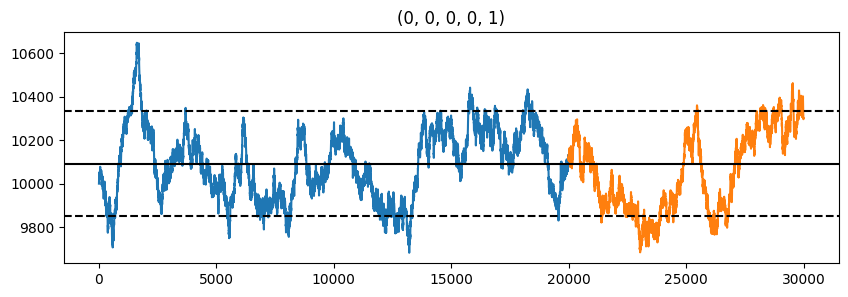

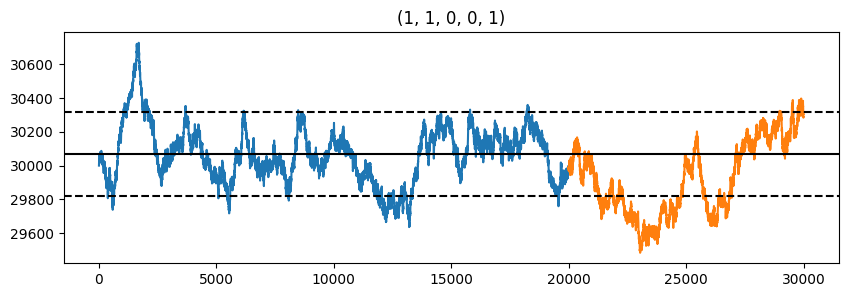

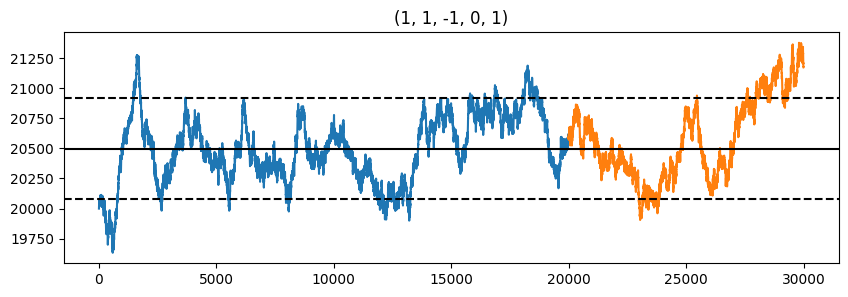

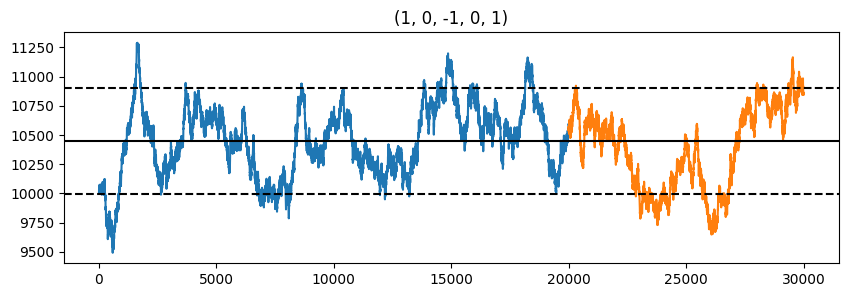

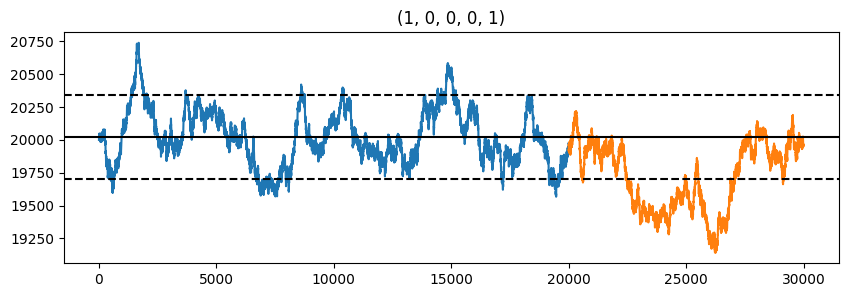

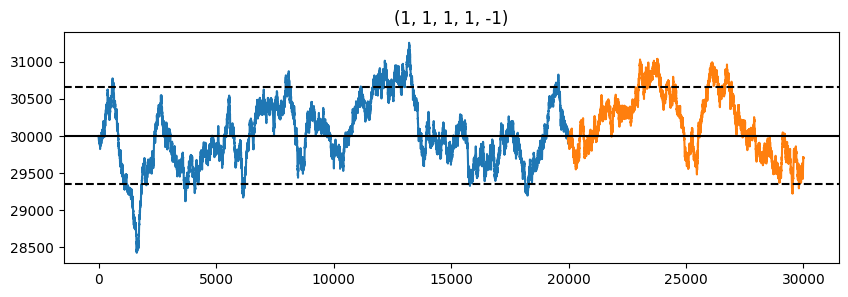

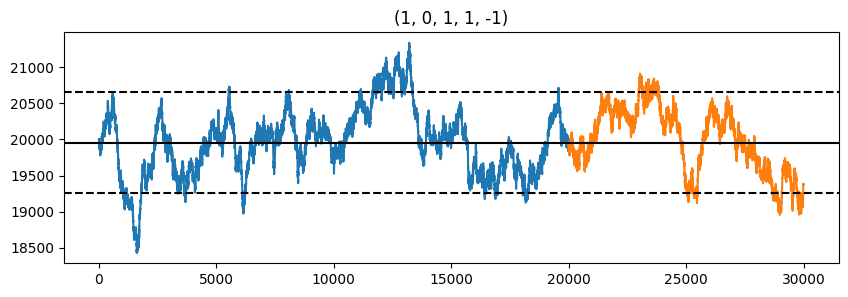

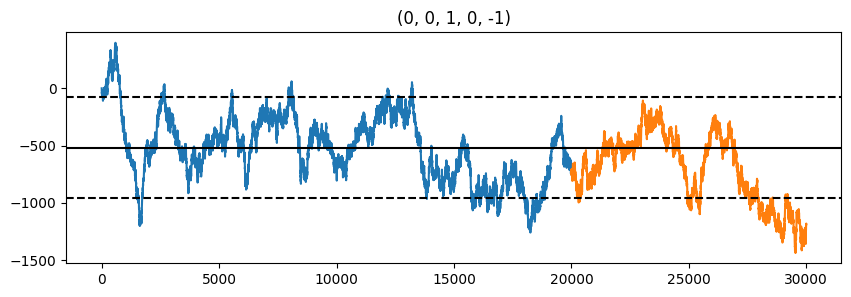

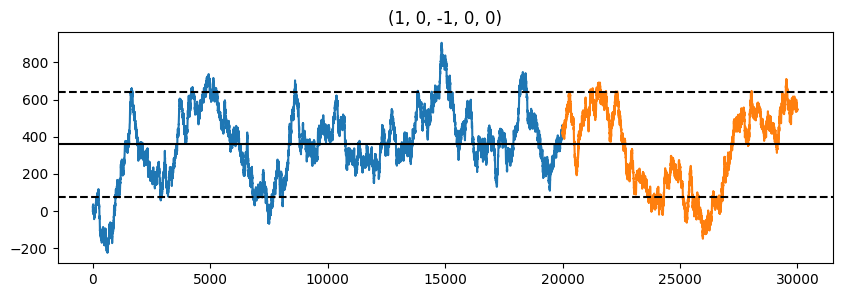

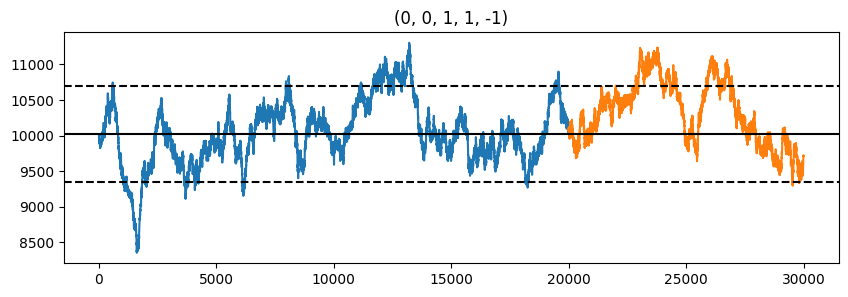

#################################################################################################################################################


In [17]:
for i in range(len(prices)):
    p_list = prices_train[i]
    p_list_1 = prices_test[i]
    optimal_baskets, assets = find_smallest_optimal_baskets(p_list)
    for w in optimal_baskets.iloc[:10]['Weights']:
        mids = [p['mid_price'].values for p in p_list]
        mids_1 = [p['mid_price'].values for p in p_list_1]
        spr = np.matmul(w, np.array(mids))
        spr_1 = np.matmul(w, np.array(mids_1))
        plt.figure(figsize=(10, 3))
        plt.plot(spr)
        plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
        plt.axhline(spr.mean(), c='k')
        plt.axhline(spr.mean() + 1.5 * spr.std(), c='k', linestyle='dashed')
        plt.axhline(spr.mean() - 1.5 * spr.std(), c='k', linestyle='dashed')
        plt.title(w)
        plt.show()
    print("#" * 145)

- GALAXY: None
- SLEEP: 1, -1, -1, 1, 0
- MICROCHIP: 1, 1, 0, -1, -1
- PEBBLES: 1, 1, 1, 1, 1
- ROBOT: 1, 1, 1, 0, 1
- UV: None
- TRANSLATOR: 0, 1, -1, 0, 1
- PANEL: None
- OXYGEN: 1, 1, 0, -1, 1
- SNACKPACK: 0, 0, 0, 0, 1

## SLEEP

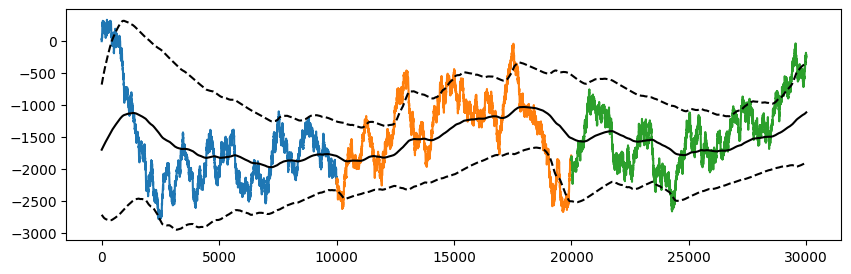

In [62]:
w = (1, -1, -1, 1, 0)

mids = [p['mid_price'].values for p in prices[1]]
mids_1 = [p['mid_price'].values for p in prices_1[1]]
mids_2 = [p['mid_price'].values for p in prices_2[1]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=5000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()

## MICROCHIP

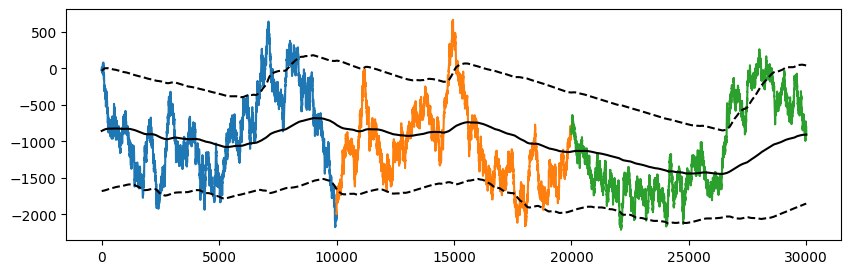

In [40]:
w = (1, 1, 0, -1, -1)

mids = [p['mid_price'].values for p in prices[2]]
mids_1 = [p['mid_price'].values for p in prices_1[2]]
mids_2 = [p['mid_price'].values for p in prices_2[2]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=10000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()

## PEBBLES

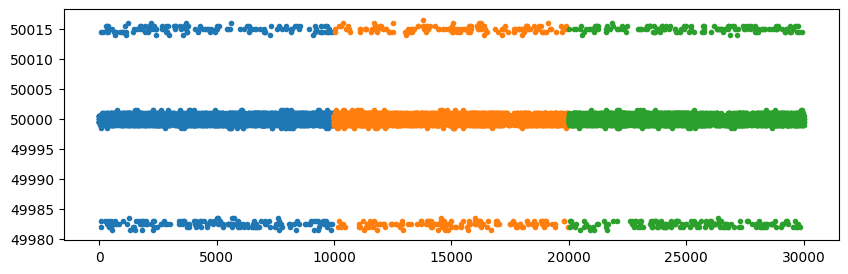

In [46]:
w = (1, 1, 1, 1, 1)

mids = [p['mid_price'].values for p in prices[3]]
mids_1 = [p['mid_price'].values for p in prices_1[3]]
mids_2 = [p['mid_price'].values for p in prices_2[3]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

plt.figure(figsize=(10, 3))
plt.scatter(np.arange(len(spr)), spr, marker='.')
plt.scatter(np.arange(len(spr), len(spr) + len(spr_1)), spr_1, marker='.')
plt.scatter(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2, marker='.')
plt.show()

## ROBOT

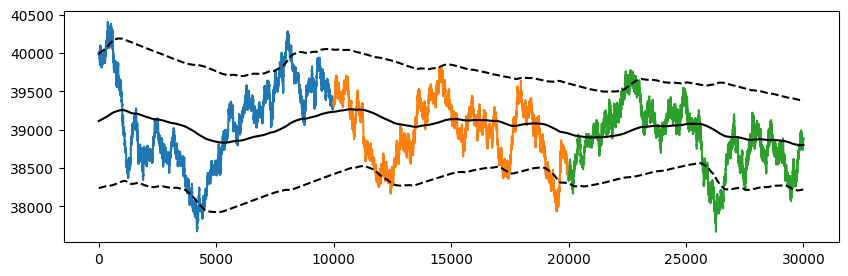

In [49]:
w = (1, 1, 1, 0, 1)

mids = [p['mid_price'].values for p in prices[4]]
mids_1 = [p['mid_price'].values for p in prices_1[4]]
mids_2 = [p['mid_price'].values for p in prices_2[4]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=10000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()

## TRANSLATOR

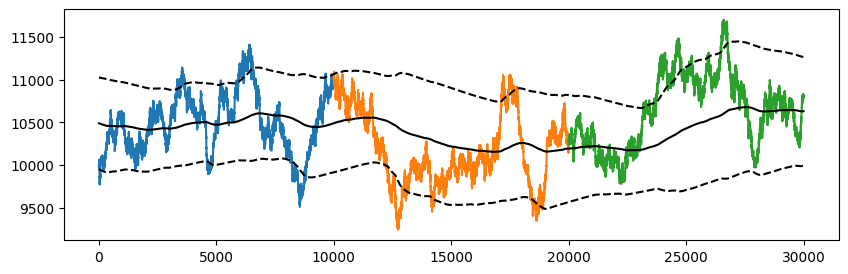

In [50]:
w = (0, 1, -1, 0, 1)

mids = [p['mid_price'].values for p in prices[6]]
mids_1 = [p['mid_price'].values for p in prices_1[6]]
mids_2 = [p['mid_price'].values for p in prices_2[6]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=10000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()

## OXYGEN

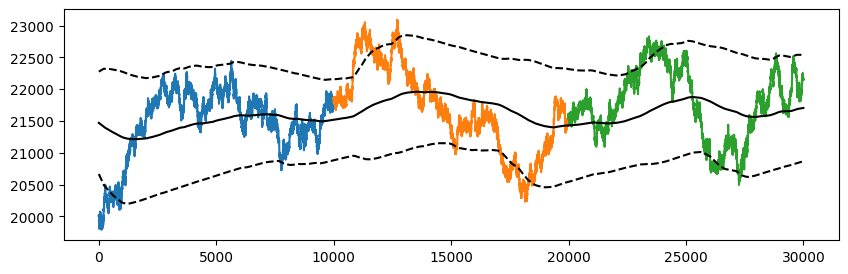

In [51]:
w = (1, 1, 0, -1, 1)

mids = [p['mid_price'].values for p in prices[8]]
mids_1 = [p['mid_price'].values for p in prices_1[8]]
mids_2 = [p['mid_price'].values for p in prices_2[8]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=10000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()

## SNACKPACK

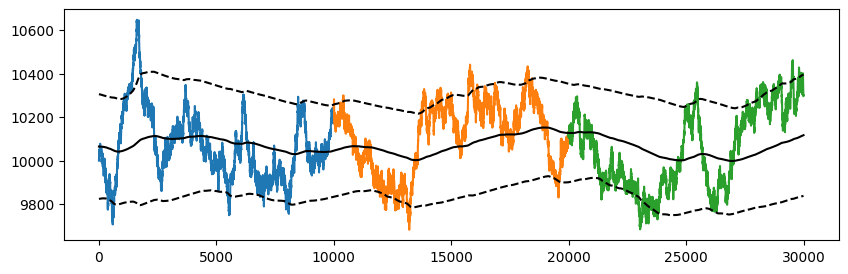

In [52]:
w = (0, 0, 0, 0, 1)

mids = [p['mid_price'].values for p in prices[9]]
mids_1 = [p['mid_price'].values for p in prices_1[9]]
mids_2 = [p['mid_price'].values for p in prices_2[9]]

spr = np.matmul(w, np.array(mids))
spr_1 = np.matmul(w, np.array(mids_1))
spr_2 = np.matmul(w, np.array(mids_2))

ema_mean, ema_std = get_ema_thrs(price_arr=np.concatenate([spr, spr_1, spr_2]), window_size=10000, init_mean=spr.mean(), init_std=spr.std())

plt.figure(figsize=(10, 3))
plt.plot(spr)
plt.plot(np.arange(len(spr), len(spr) + len(spr_1)), spr_1)
plt.plot(np.arange(len(spr) + len(spr_1), len(spr) + len(spr_1) + len(spr_2)), spr_2)
plt.plot(ema_mean, c='k')
plt.plot(ema_mean + 1.5 * ema_std, c='k', linestyle='dashed')
plt.plot(ema_mean - 1.5 * ema_std, c='k', linestyle='dashed')
plt.show()